In [1]:
# ============================================================
# 1. LOAD COINTEGRATION EFFICIENCY
# ============================================================

import pandas as pd
import numpy as np

cointegration_path = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/replicon_cointegration_conditional.csv"

cointegration = pd.read_csv(cointegration_path)

# Normalizar clave de par
cointegration["rep_pair"] = cointegration.apply(
    lambda r: " || ".join(sorted([str(r["repA"]), str(r["repB"])])),
    axis=1
)

print("Cointegration loaded:", cointegration.shape)
cointegration.head()


Cointegration loaded: (2047, 9)


,repA,repB,n_same_cell,n_cell_same_plasmid,cointegration_rate,ci_low,ci_high,category,rep_pair
0,ColpVC,IncN,16,1,0.062500,0.001581,0.302321,STRONG_REPULSION,ColpVC || IncN
1,ColpVC,rep_cluster_2335,50,0,0.000000,0.000000,0.071122,STRONG_REPULSION,ColpVC || rep_cluster_2335
2,IncN,rep_cluster_2335,71,1,0.014085,0.000357,0.075993,STRONG_REPULSION,IncN || rep_cluster_2335
3,IncFIB,IncFII,3035,2410,0.794069,0.779238,0.808332,MIXED,IncFIB || IncFII
4,IncFIB,IncR,807,67,0.083024,0.064919,0.104240,STRONG_REPULSION,IncFIB || IncR


In [2]:
# ============================================================
# 2. LOAD DISTANCES + SUMMARIZE (MAD + QCV)
# ============================================================

pairs_path = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/replicon_distances.tsv"

pairs = pd.read_csv(pairs_path, sep="\t")

pairs["rep_pair"] = pairs.apply(
    lambda r: " || ".join(sorted([str(r["replicon_1"]), str(r["replicon_2"])])),
    axis=1
)

MIN_N = 5

rep_stats = (
    pairs
    .groupby("rep_pair")
    .agg(n=("distance_absolute", "count"))
)

rep_stats = rep_stats[rep_stats["n"] >= MIN_N].copy()

# ------------------------------------------------------------
# Compute robust statistics
# ------------------------------------------------------------

med_abs, mad_abs, qcv_abs = [], [], []
med_rel, mad_rel, qcv_rel = [], [], []

for rp in rep_stats.index:
    sub = pairs[pairs["rep_pair"] == rp]
    
    d_abs = sub["distance_absolute"].dropna()
    d_rel = sub["distance_relative"].dropna()
    
    # =========================
    # ABSOLUTE DISTANCE
    # =========================
    med_a = d_abs.median()
    med_abs.append(med_a)
    
    mad_abs.append(np.median(np.abs(d_abs - med_a)))
    
    q1_a = np.percentile(d_abs, 25)
    q3_a = np.percentile(d_abs, 75)
    
    if (q3_a + q1_a) > 0:
        qcv_abs.append((q3_a - q1_a) / (q3_a + q1_a))
    else:
        qcv_abs.append(np.nan)
    
    # =========================
    # RELATIVE DISTANCE
    # =========================
    med_r = d_rel.median()
    med_rel.append(med_r)
    
    mad_rel.append(np.median(np.abs(d_rel - med_r)))
    
    q1_r = np.percentile(d_rel, 25)
    q3_r = np.percentile(d_rel, 75)
    
    if (q3_r + q1_r) > 0:
        qcv_rel.append((q3_r - q1_r) / (q3_r + q1_r))
    else:
        qcv_rel.append(np.nan)

# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

rep_stats["median_abs"] = med_abs
rep_stats["median_rel"] = med_rel
rep_stats["MAD_abs"] = mad_abs
rep_stats["MAD_rel"] = mad_rel
rep_stats["QCV_abs"] = qcv_abs
rep_stats["QCV_rel"] = qcv_rel

print("Distance stats:", rep_stats.shape)
rep_stats.head()


Distance stats: (349, 7)


,n,median_abs,median_rel,MAD_abs,MAD_rel,QCV_abs,QCV_rel
rep_pair,,,,,,,
Col156 || IncFIA,6,33126.0,0.327496,12506.5,0.036518,0.247496,0.199114
Col156 || IncFIB,5,23287.0,0.194631,9974.0,0.112182,0.406890,0.398571
Col156 || rep_cluster_2131,7,279.0,0.046215,237.0,0.039571,0.893186,0.565095
ColRNAI_rep_cluster_1857 || ColRNAI_rep_cluster_1857,5,161.0,0.009136,122.0,0.005999,0.695312,0.575268
ColRNAI_rep_cluster_1857 || IncFIA,17,31059.0,0.244490,5662.0,0.074977,0.292080,0.349987


In [3]:
# ============================================================
# 3. LOAD MANTEL RESULTS (ROBUST PARSING)
# ============================================================

mantel_path = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/treesreplicons/pairwise_mantel_results.tsv"

mantel = pd.read_csv(mantel_path, sep="\t")

# Filtrar significativos
mantel = mantel[mantel["mantel_p"] <= 0.05].copy()

print("Mantel rows after p-filter:", mantel.shape)

# ------------------------------------------------------------
# Robust pair normalization
# ------------------------------------------------------------

def normalize_pair_key(s):
    if pd.isna(s):
        return np.nan
    
    s = str(s).strip()
    
    # posibles separadores
    for sep in ["||", "__", " vs ", "|", ","]:
        if sep in s:
            parts = [x.strip() for x in s.split(sep)]
            if len(parts) >= 2:
                a, b = parts[0], parts[1]
                return " || ".join(sorted([a, b]))
    
    # fallback: separar por espacio
    parts = s.split()
    if len(parts) >= 2:
        a, b = parts[0], parts[-1]
        return " || ".join(sorted([a, b]))
    
    # si no se puede parsear
    return np.nan


mantel["rep_pair"] = mantel["pair"].apply(normalize_pair_key)

# Eliminar fallos de parsing
mantel = mantel.dropna(subset=["rep_pair"])

mantel = mantel[["rep_pair", "mantel_r"]]

print("Mantel usable pairs:", mantel.shape)
mantel.head()


Mantel rows after p-filter: (104, 8)
Mantel usable pairs: (104, 2)


,rep_pair,mantel_r
0,Col156 || IncFIA,0.698253
3,ColRNAI_rep_cluster_1857 || IncFIA,0.410544
4,ColRNAI_rep_cluster_1857 || IncFIB,0.426651
5,ColRNAI_rep_cluster_1857 || IncFIC,0.999345
16,ColRNAI_rep_cluster_1987 || rep_cluster_2358,0.133410


In [4]:
merged = (
    cointegration
    .merge(rep_stats.reset_index(), on="rep_pair", how="inner")
    .merge(mantel, on="rep_pair", how="inner")
)

print("Merged shape:", merged.shape)


Merged shape: (101, 17)


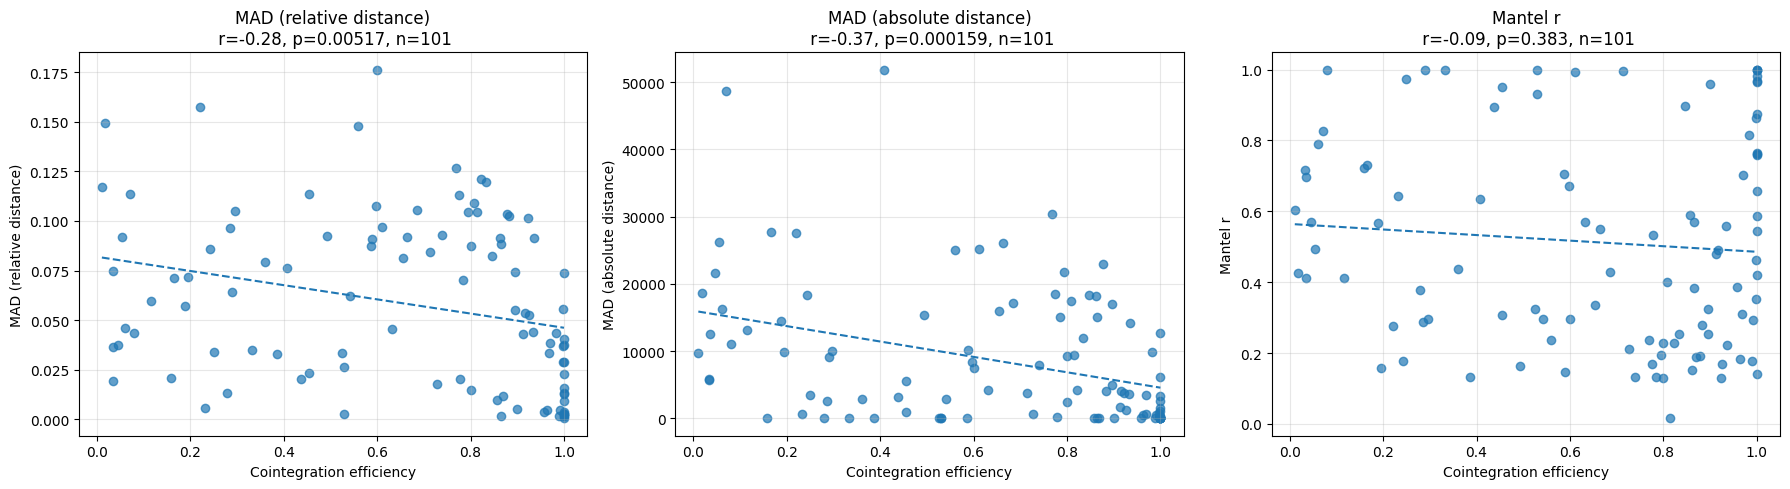

In [5]:
# ============================================================
# 1. SCATTERPLOTS
# ============================================================

import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plots = [
    ("MAD_rel", "MAD (relative distance)"),
    ("MAD_abs", "MAD (absolute distance)"),
    ("mantel_r", "Mantel r")
]

for ax, (col, label) in zip(axes, plots):
    
    x = merged["cointegration_rate"]
    y = merged[col]
    
    mask = x.notna() & y.notna()
    
    ax.scatter(x[mask], y[mask], alpha=0.7)
    
    # Línea de tendencia
    if mask.sum() > 5:
        slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, intercept + slope * xs, linestyle="--")
        ax.set_title(f"{label}\n r={r:.2f}, p={p:.3g}, n={mask.sum()}")
    else:
        ax.set_title(f"{label} (n={mask.sum()})")
    
    ax.set_xlabel("Cointegration efficiency")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
import numpy as np

# ============================================================
# 2. PROPORTION ANALYSIS FOR HIGH MANTEL
# ============================================================

# Definir umbrales
mantel_thr = 0.9
cointeg_thr = 0.8

# Filtrar casos con mantel alto
subset = merged[
    (merged["mantel_r"].notna()) &
    (merged["cointegration_rate"].notna()) &
    (merged["mantel_r"] > mantel_thr)
]

n_total = len(subset)

if n_total == 0:
    print("No cases with mantel_r > 0.8")
else:
    n_high_cointeg = (subset["cointegration_rate"] > cointeg_thr).sum()
    n_low_cointeg  = (subset["cointegration_rate"] <= cointeg_thr).sum()
    
    prop_high = n_high_cointeg / n_total
    prop_low  = n_low_cointeg  / n_total
    
    print("=== High Mantel (>0.8) analysis ===")
    print(f"Total cases: {n_total}")
    print(f"Cointegration > 0.8: {n_high_cointeg} ({prop_high:.3f})")
    print(f"Cointegration ≤ 0.8: {n_low_cointeg} ({prop_low:.3f})")


=== High Mantel (>0.8) analysis ===
Total cases: 16
Cointegration > 0.8: 7 (0.438)
Cointegration ≤ 0.8: 9 (0.562)


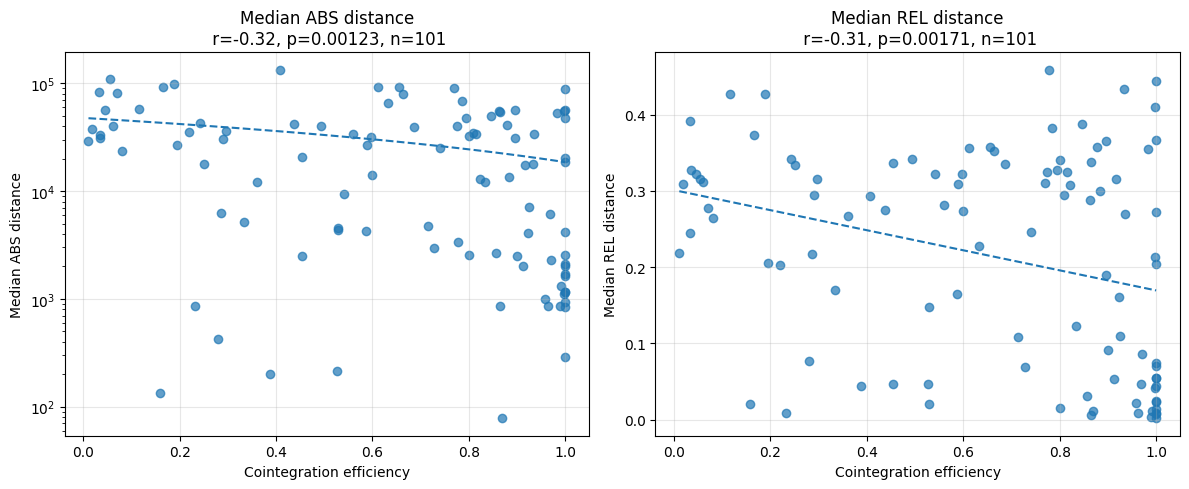

In [7]:
# ============================================================
# COINTEGRATION vs MEDIAN DISTANCE
# ============================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    ("median_abs", "Median ABS distance"),
    ("median_rel", "Median REL distance")
]

for ax, (col, label) in zip(axes, plots):
    
    x = merged["cointegration_rate"]
    y = merged[col]
    
    mask = x.notna() & y.notna()
    
    ax.scatter(x[mask], y[mask], alpha=0.7)
    
    # Línea tendencia
    if mask.sum() > 5:
        slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, intercept + slope * xs, linestyle="--")
        ax.set_title(f"{label}\n r={r:.2f}, p={p:.3g}, n={mask.sum()}")
    else:
        ax.set_title(f"{label} (n={mask.sum()})")
    
    ax.set_xlabel("Cointegration efficiency")
    ax.set_ylabel(label)
    
    # ABS suele estar en log-scale
    if "abs" in col:
        ax.set_yscale("log")
    
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# 2. CORRELATION TESTS
# ============================================================

def corr_report(x, y, label):
    mask = x.notna() & y.notna()
    n = mask.sum()
    
    if n < 5:
        print(f"{label}: n too small")
        return
    
    sp = stats.spearmanr(x[mask], y[mask])
    
    print(f"\n--- {label} ---")
    print(f"Spearman rho = {sp.correlation:.4f}")
    print(f"p-value      = {sp.pvalue:.4g}")
    print(f"n            = {n}")


corr_report(merged["cointegration_rate"], merged["MAD_rel"],
            "Efficiency vs MAD_rel")

corr_report(merged["cointegration_rate"], merged["MAD_abs"],
            "Efficiency vs MAD_abs")

corr_report(merged["cointegration_rate"], merged["mantel_r"],
            "Efficiency vs Mantel_r")
# ============================================================
# SPEARMAN — MEDIAN DISTANCES
# ============================================================

from scipy import stats

def corr_report(x, y, label):
    mask = x.notna() & y.notna()
    n = mask.sum()
    
    if n < 5:
        print(f"{label}: n too small ({n})")
        return
    
    sp = stats.spearmanr(x[mask], y[mask])
    
    print(f"\n--- {label} ---")
    print(f"Spearman rho = {sp.correlation:.4f}")
    print(f"p-value      = {sp.pvalue:.4g}")
    print(f"n            = {n}")


# ------------------------------------------------------------
# MEDIAN DISTANCES
# ------------------------------------------------------------

corr_report(
    merged["cointegration_rate"],
    merged["median_abs"],
    "Efficiency vs Median ABS distance"
)

corr_report(
    merged["cointegration_rate"],
    merged["median_rel"],
    "Efficiency vs Median REL distance"
)



--- Efficiency vs MAD_rel ---
Spearman rho = -0.3920
p-value      = 5.04e-05
n            = 101

--- Efficiency vs MAD_abs ---
Spearman rho = -0.4409
p-value      = 3.94e-06
n            = 101

--- Efficiency vs Mantel_r ---
Spearman rho = 0.0010
p-value      = 0.9919
n            = 101

--- Efficiency vs Median ABS distance ---
Spearman rho = -0.3527
p-value      = 0.0002974
n            = 101

--- Efficiency vs Median REL distance ---
Spearman rho = -0.3116
p-value      = 0.001514
n            = 101


In [82]:
hom = pd.read_csv("/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing/replicon_pair_homology_full.tsv", sep="\t")

# crear misma llave que merged
hom["rep_pair_fixed"] = hom.apply(
    lambda x: " × ".join(sorted([x["repA"], x["repB"]])),
    axis=1
)

full = merged.merge(
    hom,
    on="rep_pair_fixed",
    how="inner"
)

print("Merged pairs:", len(full))

# ------------------------------------------------------------
# LOG TRANSFORM BACKBONE SIZE
# ------------------------------------------------------------

merged.to_csv(
    "merged_structural_metrics.tsv",
    sep="\t",
    index=False
)

full.to_csv(
    "full_structural_homology_metrics.tsv",
    sep="\t",
    index=False
)

print("Export complete.")

Merged pairs: 90
Export complete.


Real median QCV_rel: 0.3015
Null median QCV_rel: 0.4505
Mann-Whitney U p-value: 6.187e-14


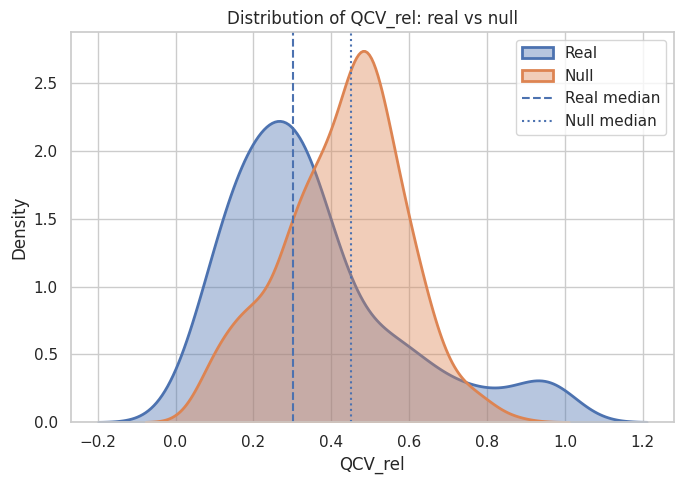

In [169]:
# ============================================================
# DENSITY PLOT: QCV_rel REAL vs NULL
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1. LONG FORMAT
# ------------------------------------------------------------

dens_df = pd.concat([
    qcv_compare[["rep_pair", "QCV_rel_real"]]
        .rename(columns={"QCV_rel_real": "QCV_rel"})
        .assign(group="Real"),
    
    qcv_compare[["rep_pair", "QCV_rel_null"]]
        .rename(columns={"QCV_rel_null": "QCV_rel"})
        .assign(group="Null")
], ignore_index=True)

dens_df = dens_df.dropna(subset=["QCV_rel"])

# ------------------------------------------------------------
# 2. STATS
# ------------------------------------------------------------

real_vals = qcv_compare["QCV_rel_real"].dropna()
null_vals = qcv_compare["QCV_rel_null"].dropna()

u, p = mannwhitneyu(real_vals, null_vals, alternative="two-sided")

print(f"Real median QCV_rel: {real_vals.median():.4f}")
print(f"Null median QCV_rel: {null_vals.median():.4f}")
print(f"Mann-Whitney U p-value: {p:.3e}")

# ------------------------------------------------------------
# 3. DENSITY PLOT
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.kdeplot(
    data=dens_df[dens_df["group"] == "Real"],
    x="QCV_rel",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    label="Real"
)

sns.kdeplot(
    data=dens_df[dens_df["group"] == "Null"],
    x="QCV_rel",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    label="Null"
)

plt.axvline(real_vals.median(), linestyle="--", linewidth=1.5, label="Real median")
plt.axvline(null_vals.median(), linestyle=":", linewidth=1.5, label="Null median")

plt.xlabel("QCV_rel")
plt.ylabel("Density")
plt.title("Distribution of QCV_rel: real vs null")
plt.legend()
plt.tight_layout()
plt.show()

In [171]:
# ============================================================
# TABLE + KS TEST: QCV_rel REAL vs NULL
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import ks_2samp

# ------------------------------------------------------------
# 1. BUILD TABLE (LONG FORMAT)
# ------------------------------------------------------------

qcv_table = pd.concat([
    qcv_compare[["rep_pair", "QCV_rel_real"]]
        .rename(columns={"QCV_rel_real": "QCV_rel"})
        .assign(group="Real"),
    
    qcv_compare[["rep_pair", "QCV_rel_null"]]
        .rename(columns={"QCV_rel_null": "QCV_rel"})
        .assign(group="Null")
], ignore_index=True)

qcv_table = qcv_table.dropna(subset=["QCV_rel"])

print("Table shape:", qcv_table.shape)
display(qcv_table.head())

# ------------------------------------------------------------
# 2. EXTRACT VECTORS
# ------------------------------------------------------------

real_vals = qcv_compare["QCV_rel_real"].dropna().values
null_vals = qcv_compare["QCV_rel_null"].dropna().values

# ------------------------------------------------------------
# 3. KS TEST
# ------------------------------------------------------------

ks_stat, ks_p = ks_2samp(real_vals, null_vals)

print(f"KS statistic = {ks_stat:.4f}")
print(f"KS p-value   = {ks_p:.3e}")

# ------------------------------------------------------------
# 4. SUMMARY TABLE
# ------------------------------------------------------------

summary = pd.DataFrame({
    "group": ["Real", "Null"],
    "n": [len(real_vals), len(null_vals)],
    "mean": [np.mean(real_vals), np.mean(null_vals)],
    "median": [np.median(real_vals), np.median(null_vals)],
    "std": [np.std(real_vals), np.std(null_vals)]
})

display(summary)
# ============================================================
# SAVE TABLE
# ============================================================

out_tsv = "/home/nacho/HDD16/Nacho/RepliCOOC/qcv_real_vs_null.tsv"

# TSV (legible)
qcv_table.to_csv(out_tsv, sep="\t", index=False)



print("Saved:")
print(out_tsv)


Table shape: (698, 3)


,rep_pair,QCV_rel,group
0,Col156 || IncFIA,0.199114,Real
1,Col156 || IncFIB,0.398571,Real
2,Col156 || rep_cluster_2131,0.565095,Real
3,ColRNAI_rep_cluster_1857 || ColRNAI_rep_cluste...,0.575268,Real
4,ColRNAI_rep_cluster_1857 || IncFIA,0.349987,Real


KS statistic = 0.3410
KS p-value   = 2.226e-18


,group,n,mean,median,std
0,Real,349,0.352779,0.301458,0.225127
1,Null,349,0.430100,0.450472,0.154324


Saved:
/home/nacho/HDD16/Nacho/RepliCOOC/qcv_real_vs_null.tsv


/tmp/ipykernel_2926773/890286060.py:76: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = p_matrix_fdr.applymap(significance_symbol)


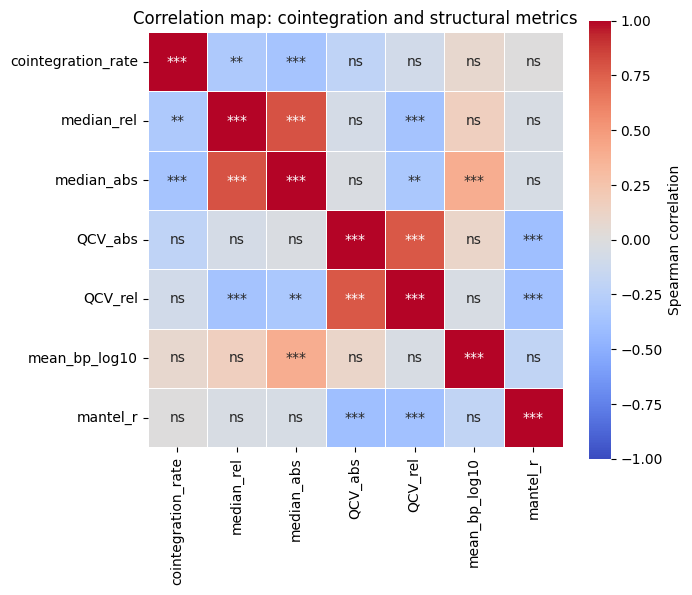

In [77]:
# ============================================================
# PANEL D — CORRELATION MAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Variables a incluir
# ------------------------------------------------------------

vars_of_interest = [
    "cointegration_rate",
    "median_rel","median_abs","QCV_abs", "QCV_rel","mean_bp_log10",
    "mantel_r"
]

df = merged[vars_of_interest].copy()

# ------------------------------------------------------------
# Compute Spearman correlations + p-values
# ------------------------------------------------------------

corr_matrix = pd.DataFrame(index=vars_of_interest,
                           columns=vars_of_interest,
                           dtype=float)

p_matrix = corr_matrix.copy()

for v1 in vars_of_interest:
    for v2 in vars_of_interest:
        mask = df[v1].notna() & df[v2].notna()
        if mask.sum() >= 5:
            r, p = spearmanr(df.loc[mask, v1], df.loc[mask, v2])
        else:
            r, p = np.nan, np.nan
        
        corr_matrix.loc[v1, v2] = r
        p_matrix.loc[v1, v2] = p

# ------------------------------------------------------------
# FDR correction (optional but recommended)
# ------------------------------------------------------------

# Flatten upper triangle (excluding diagonal)
tri_mask = np.triu(np.ones(p_matrix.shape), k=1).astype(bool)
pvals = p_matrix.where(tri_mask).stack().values

reject, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

# Put corrected p-values back
p_matrix_fdr = p_matrix.copy()
p_matrix_fdr.values[tri_mask] = pvals_fdr
p_matrix_fdr.values.T[tri_mask] = pvals_fdr

# ------------------------------------------------------------
# Create significance annotation matrix
# ------------------------------------------------------------

def significance_symbol(p):
    if np.isnan(p):
        return ""
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

annot_matrix = p_matrix_fdr.applymap(significance_symbol)

# Force explicit "ns" display for Mantel links
for var in vars_of_interest:
    if var != "mantel_r":
        if annot_matrix.loc[var, "mantel_r"] == "":
            annot_matrix.loc[var, "mantel_r"] = "ns"
        if annot_matrix.loc["mantel_r", var] == "":
            annot_matrix.loc["mantel_r", var] = "ns"

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr_matrix.astype(float),
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Spearman correlation"}
)

plt.title("Correlation map: cointegration and structural metrics")
plt.tight_layout()
plt.show()


Total unique pairs (no restriction): (2082, 7)


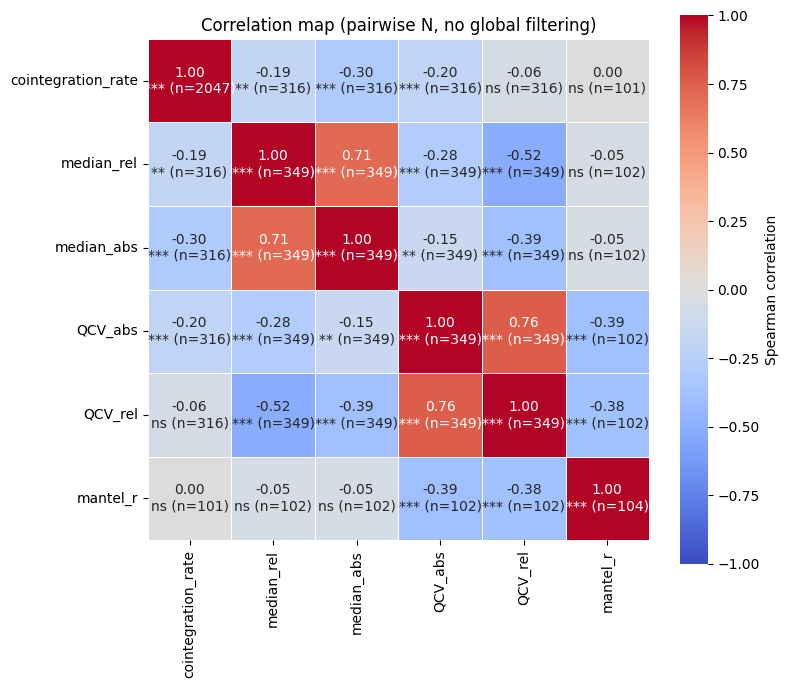

In [89]:
# ============================================================
# REBUILD FULL TABLE (NO INFORMATION LOSS)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 1. Harmonize pair keys
# ------------------------------------------------------------

cointegration_sub = cointegration[["rep_pair", "cointegration_rate"]].copy()

rep_stats_sub = rep_stats.reset_index()[[
    "rep_pair",
    "median_abs", "median_rel",
    "QCV_abs", "QCV_rel"
]].copy()

mantel_sub = mantel[["rep_pair", "mantel_r"]].copy()

# ------------------------------------------------------------
# 2. OUTER MERGE (critical step)
# ------------------------------------------------------------

struct_all = (
    cointegration_sub
    .merge(rep_stats_sub, on="rep_pair", how="outer")
    .merge(mantel_sub, on="rep_pair", how="outer")
)

print("Total unique pairs (no restriction):", struct_all.shape)

# ------------------------------------------------------------
# 3. Variables for correlation
# ------------------------------------------------------------

vars_of_interest = [
    "cointegration_rate",
    "median_rel", "median_abs",
    "QCV_abs", "QCV_rel",
    "mantel_r"
]

# ------------------------------------------------------------
# 4. Pairwise Spearman (variable N)
# ------------------------------------------------------------

corr_matrix = pd.DataFrame(index=vars_of_interest,
                           columns=vars_of_interest,
                           dtype=float)

p_matrix = corr_matrix.copy()
n_matrix = corr_matrix.copy()

for v1 in vars_of_interest:
    for v2 in vars_of_interest:
        
        mask = struct_all[v1].notna() & struct_all[v2].notna()
        n = mask.sum()
        
        if n >= 5:
            r, p = spearmanr(struct_all.loc[mask, v1],
                             struct_all.loc[mask, v2])
        else:
            r, p = np.nan, np.nan
        
        corr_matrix.loc[v1, v2] = r
        p_matrix.loc[v1, v2] = p
        n_matrix.loc[v1, v2] = n

# ------------------------------------------------------------
# 5. FDR correction (upper triangle)
# ------------------------------------------------------------

tri_mask = np.triu(np.ones(p_matrix.shape), k=1).astype(bool)
pvals = p_matrix.where(tri_mask).stack().values

reject, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")

p_matrix_fdr = p_matrix.copy()
p_matrix_fdr.values[tri_mask] = pvals_fdr
p_matrix_fdr.values.T[tri_mask] = pvals_fdr

# ------------------------------------------------------------
# 6. Annotation matrix
# ------------------------------------------------------------

def significance_symbol(p):
    if np.isnan(p):
        return ""
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

annot_matrix = pd.DataFrame(index=vars_of_interest,
                            columns=vars_of_interest,
                            dtype=str)

for v1 in vars_of_interest:
    for v2 in vars_of_interest:
        
        r = corr_matrix.loc[v1, v2]
        p = p_matrix_fdr.loc[v1, v2]
        n = int(n_matrix.loc[v1, v2])
        
        if np.isnan(r):
            annot_matrix.loc[v1, v2] = ""
        else:
            annot_matrix.loc[v1, v2] = f"{r:.2f}\n{significance_symbol(p)} (n={n})"

# ------------------------------------------------------------
# 7. Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

sns.heatmap(
    corr_matrix.astype(float),
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Spearman correlation"}
)

plt.title("Correlation map (pairwise N, no global filtering)")
plt.tight_layout()
plt.show()

Non-NaN significant mantel_multirep: 100
Non-NaN significant mantel_singlereps: 73
Total unique pairs (no restriction): (2100, 8)


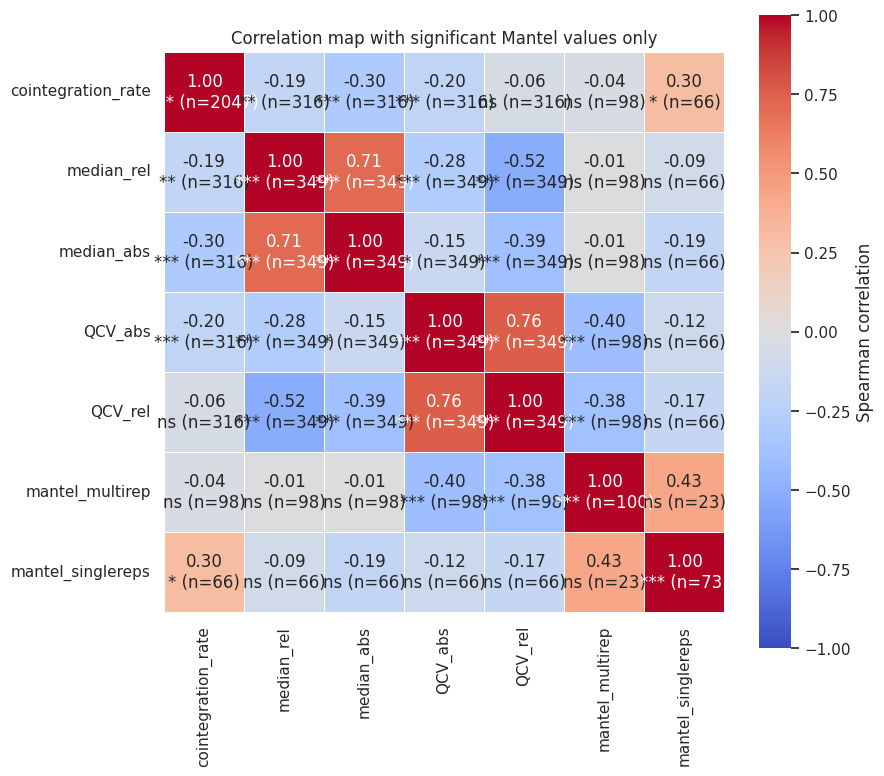

In [153]:
# ============================================================
# REBUILD FULL TABLE + KEEP ONLY SIGNIFICANT MANTEL VALUES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 0. INPUTS
# ------------------------------------------------------------

MANTEL_MULTIREP_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/treesreplicons/pairwise_mantel_results.tsv"
MANTEL_SINGLEREPS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/control_fastas/pairwise_mantel_results_control.tsv"

PV_CUTOFF = 0.05

# ------------------------------------------------------------
# 1. LOAD BOTH MANTEL TABLES
# ------------------------------------------------------------

mantel_multirep = pd.read_csv(MANTEL_MULTIREP_FILE, sep="\t")
mantel_singlereps = pd.read_csv(MANTEL_SINGLEREPS_FILE, sep="\t")

def clean_rep(x):
    x = str(x).strip()
    x = x.replace("_all_aligned.fasta", "")
    x = x.replace("_aligned.fasta", "")
    x = x.replace(".fasta", "")
    return x

def canon_pair(a, b):
    return " || ".join(sorted([str(a), str(b)]))

# build rep_pair if needed
if "rep_pair" not in mantel_multirep.columns:
    mantel_multirep["repA"] = mantel_multirep["repA"].apply(clean_rep)
    mantel_multirep["repB"] = mantel_multirep["repB"].apply(clean_rep)
    mantel_multirep["rep_pair"] = mantel_multirep.apply(
        lambda r: canon_pair(r["repA"], r["repB"]), axis=1
    )

if "rep_pair" not in mantel_singlereps.columns:
    mantel_singlereps["repA"] = mantel_singlereps["repA"].apply(clean_rep)
    mantel_singlereps["repB"] = mantel_singlereps["repB"].apply(clean_rep)
    mantel_singlereps["rep_pair"] = mantel_singlereps.apply(
        lambda r: canon_pair(r["repA"], r["repB"]), axis=1
    )

# ensure numeric
mantel_multirep["mantel_r"] = pd.to_numeric(mantel_multirep["mantel_r"], errors="coerce")
mantel_multirep["mantel_p"] = pd.to_numeric(mantel_multirep["mantel_p"], errors="coerce")

mantel_singlereps["mantel_r"] = pd.to_numeric(mantel_singlereps["mantel_r"], errors="coerce")
mantel_singlereps["mantel_p"] = pd.to_numeric(mantel_singlereps["mantel_p"], errors="coerce")

# keep only significant mantel values
mantel_multirep.loc[mantel_multirep["mantel_p"] >= PV_CUTOFF, "mantel_r"] = np.nan
mantel_singlereps.loc[mantel_singlereps["mantel_p"] >= PV_CUTOFF, "mantel_r"] = np.nan

# rename mantel columns
mantel_multirep_sub = mantel_multirep[["rep_pair", "mantel_r"]].copy()
mantel_multirep_sub = mantel_multirep_sub.rename(columns={"mantel_r": "mantel_multirep"})

mantel_singlereps_sub = mantel_singlereps[["rep_pair", "mantel_r"]].copy()
mantel_singlereps_sub = mantel_singlereps_sub.rename(columns={"mantel_r": "mantel_singlereps"})

print("Non-NaN significant mantel_multirep:", mantel_multirep_sub["mantel_multirep"].notna().sum())
print("Non-NaN significant mantel_singlereps:", mantel_singlereps_sub["mantel_singlereps"].notna().sum())

# ------------------------------------------------------------
# 2. SUBTABLES FROM EXISTING OBJECTS
# ------------------------------------------------------------

cointegration_sub = cointegration[["rep_pair", "cointegration_rate"]].copy()

rep_stats_sub = rep_stats.reset_index()[[
    "rep_pair",
    "median_abs", "median_rel",
    "QCV_abs", "QCV_rel"
]].copy()

# ------------------------------------------------------------
# 3. OUTER MERGE
# ------------------------------------------------------------

struct_all = (
    cointegration_sub
    .merge(rep_stats_sub, on="rep_pair", how="outer")
    .merge(mantel_multirep_sub, on="rep_pair", how="outer")
    .merge(mantel_singlereps_sub, on="rep_pair", how="outer")
)

print("Total unique pairs (no restriction):", struct_all.shape)

# ------------------------------------------------------------
# 4. Variables for correlation
# ------------------------------------------------------------

vars_of_interest = [
    "cointegration_rate",
    "median_rel", "median_abs",
    "QCV_abs", "QCV_rel",
    "mantel_multirep",
    "mantel_singlereps"
]

# ------------------------------------------------------------
# 5. Pairwise Spearman (variable N)
# ------------------------------------------------------------

corr_matrix = pd.DataFrame(index=vars_of_interest,
                           columns=vars_of_interest,
                           dtype=float)

p_matrix = corr_matrix.copy()
n_matrix = corr_matrix.copy()

for v1 in vars_of_interest:
    for v2 in vars_of_interest:
        
        mask = struct_all[v1].notna() & struct_all[v2].notna()
        n = mask.sum()
        
        if n >= 5:
            r, p = spearmanr(struct_all.loc[mask, v1],
                             struct_all.loc[mask, v2])
        else:
            r, p = np.nan, np.nan
        
        corr_matrix.loc[v1, v2] = r
        p_matrix.loc[v1, v2] = p
        n_matrix.loc[v1, v2] = n

# ------------------------------------------------------------
# 6. FDR correction (upper triangle)
# ------------------------------------------------------------

tri_mask = np.triu(np.ones(p_matrix.shape), k=1).astype(bool)
pvals = p_matrix.where(tri_mask).stack().values

reject, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")

p_matrix_fdr = p_matrix.copy()
p_matrix_fdr.values[tri_mask] = pvals_fdr
p_matrix_fdr.values.T[tri_mask] = pvals_fdr

# ------------------------------------------------------------
# 7. Annotation matrix
# ------------------------------------------------------------

def significance_symbol(p):
    if np.isnan(p):
        return ""
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

annot_matrix = pd.DataFrame(index=vars_of_interest,
                            columns=vars_of_interest,
                            dtype=str)

for v1 in vars_of_interest:
    for v2 in vars_of_interest:
        
        r = corr_matrix.loc[v1, v2]
        p = p_matrix_fdr.loc[v1, v2]
        n = int(n_matrix.loc[v1, v2])
        
        if np.isnan(r):
            annot_matrix.loc[v1, v2] = ""
        else:
            annot_matrix.loc[v1, v2] = f"{r:.2f}\n{significance_symbol(p)} (n={n})"

# ------------------------------------------------------------
# 8. Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 8))

sns.heatmap(
    corr_matrix.astype(float),
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Spearman correlation"}
)

plt.title("Correlation map with significant Mantel values only")
plt.tight_layout()
plt.show()

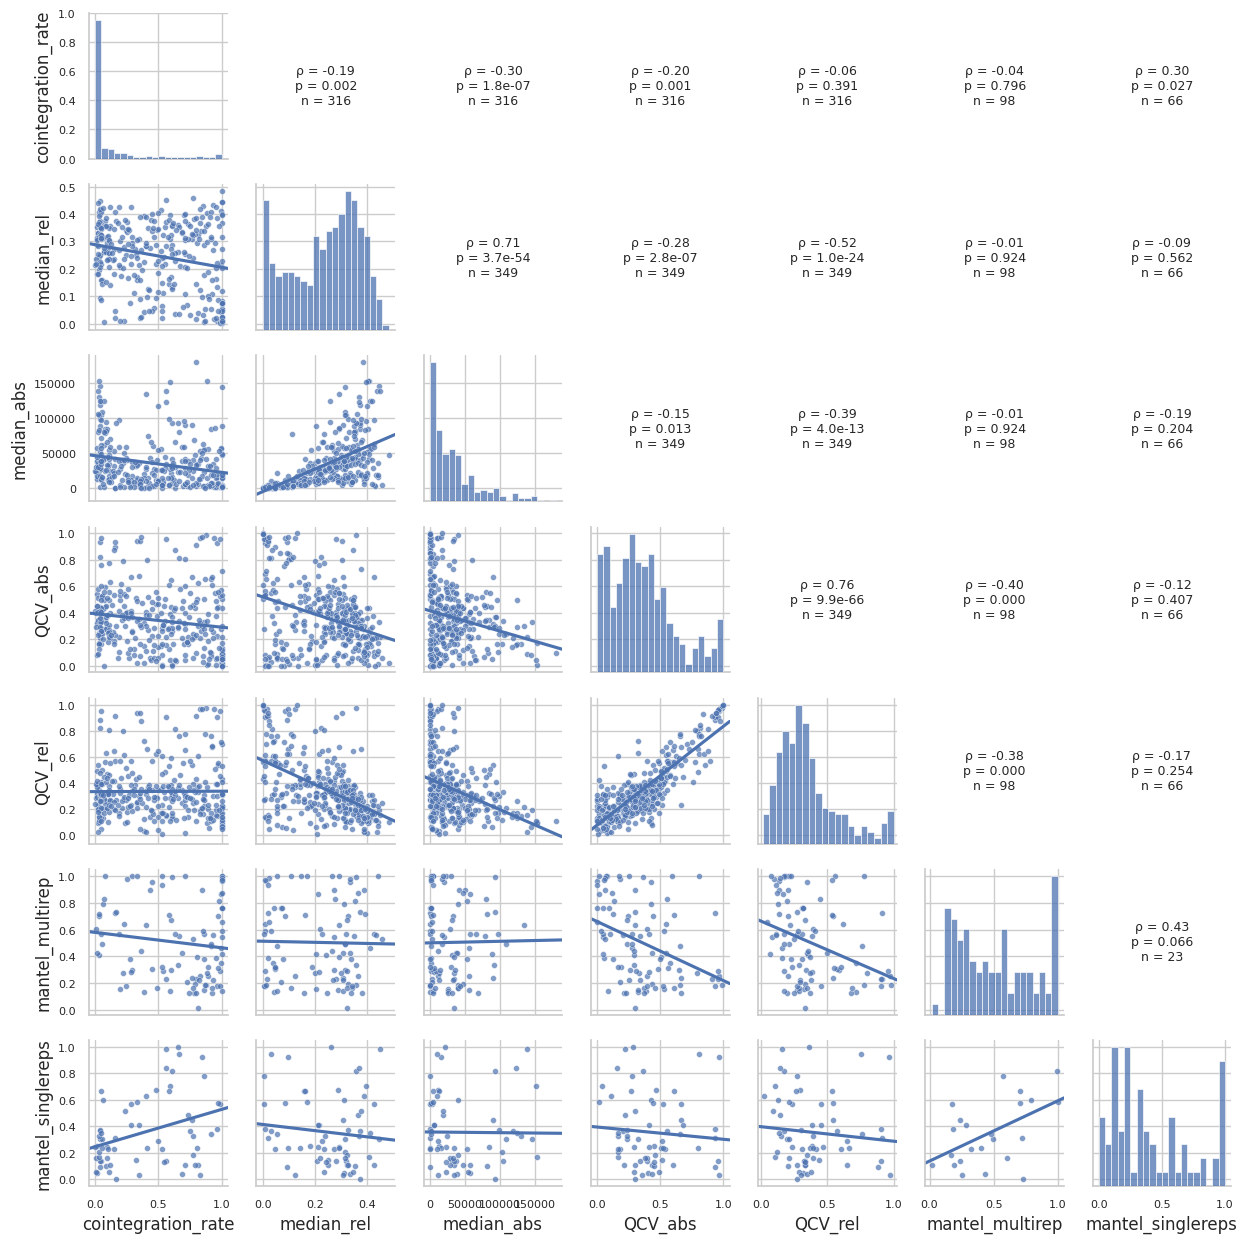

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ============================================================
# INPUT TABLE
# Assumes you already built `struct_all` with:
# cointegration_rate, median_rel, median_abs, QCV_abs, QCV_rel,
# mantel_multirep, mantel_singlereps
# and that non-significant Mantel values were already set to NaN
# ============================================================

vars_of_interest = [
    "cointegration_rate",
    "median_rel",
    "median_abs",
    "QCV_abs",
    "QCV_rel",
    "mantel_multirep",
    "mantel_singlereps"
]

df = struct_all[vars_of_interest].copy()

# optional: drop rows with everything missing except one value
df = df.dropna(how="all")

# ============================================================
# Compute all Spearman tests (for FDR)
# ============================================================

pairs = []
pvals = []

for i in range(len(vars_of_interest)):
    for j in range(i + 1, len(vars_of_interest)):
        v1 = vars_of_interest[i]
        v2 = vars_of_interest[j]
        mask = df[v1].notna() & df[v2].notna()

        if mask.sum() >= 5:
            rho, p = spearmanr(df.loc[mask, v1], df.loc[mask, v2])
        else:
            rho, p = np.nan, np.nan

        pairs.append((v1, v2, rho, p, int(mask.sum())))
        pvals.append(p)

# FDR correction
pvals_for_fdr = np.array(pvals, dtype=float)
valid = ~np.isnan(pvals_for_fdr)

pvals_fdr = np.full_like(pvals_for_fdr, np.nan, dtype=float)
if valid.sum() > 0:
    _, pvals_fdr_valid, _, _ = multipletests(pvals_for_fdr[valid], method="fdr_bh")
    pvals_fdr[valid] = pvals_fdr_valid

# Store results in dictionary
stats_dict = {}
for idx, (v1, v2, rho, _, n) in enumerate(pairs):
    stats_dict[(v1, v2)] = (rho, pvals_fdr[idx], n)
    stats_dict[(v2, v1)] = (rho, pvals_fdr[idx], n)

# ============================================================
# Pretty labels
# ============================================================

pretty = {
    "cointegration_rate": "cointegration_rate",
    "median_rel": "median_rel",
    "median_abs": "median_abs",
    "QCV_abs": "QCV_abs",
    "QCV_rel": "QCV_rel",
    "mantel_multirep": "mantel_multirep",
    "mantel_singlereps": "mantel_singlereps"
}

df_plot = df.rename(columns=pretty)

# remap stats_dict to pretty names
stats_dict_pretty = {}
for (v1, v2), (rho, p, n) in stats_dict.items():
    stats_dict_pretty[(pretty[v1], pretty[v2])] = (rho, p, n)

# ============================================================
# Custom upper panel function
# ============================================================

def corrfunc(x, y, **kws):
    ax = plt.gca()
    v1 = x.name
    v2 = y.name

    rho, p, n = stats_dict_pretty.get((v1, v2), (np.nan, np.nan, 0))

    if np.isnan(rho):
        text = "NA"
    else:
        if np.isnan(p):
            p_text = "NA"
        elif p < 1e-4:
            p_text = f"{p:.1e}"
        else:
            p_text = f"{p:.3f}"
        text = f"ρ = {rho:.2f}\np = {p_text}\nn = {n}"

    ax.annotate(
        text,
        xy=(0.5, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=9
    )
    ax.set_axis_off()

# ============================================================
# Build PairGrid
# ============================================================

g = sns.PairGrid(df_plot, vars=df_plot.columns, diag_sharey=False, height=1.8)

g.map_lower(sns.scatterplot, alpha=0.7, s=18)
g.map_lower(sns.regplot, scatter=False, ci=None, truncate=False)

g.map_diag(sns.histplot, bins=20, kde=False)

g.map_upper(corrfunc)

for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

Total multirep: 314
Total singlereps: 236
Significant multirep pairs: 100
Pairs with any single counterpart: 67
Final compared pairs: 67

Median multirep: 0.325148270685858
Median singlereps: 0.0702855821766097
Wilcoxon paired: W=239.0, p=1.888e-08
Mann–Whitney U: U=3594.0, p=1.938e-09


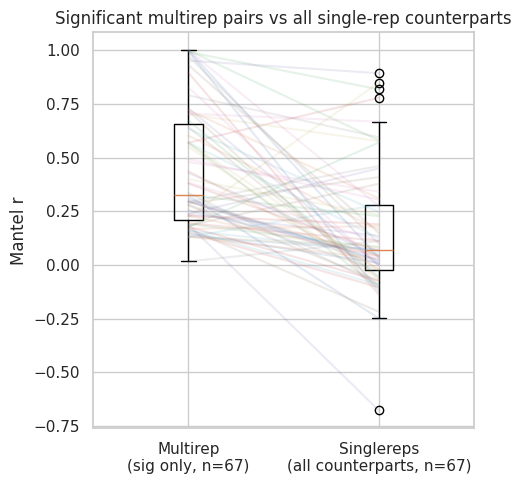

,rep_pair,mantel_multirep,mantel_p_multirep,mantel_singlereps,mantel_p_singlereps
56,rep_cluster_1215 || rep_cluster_1281,1.000000,0.000100,0.273735,0.128700
52,rep_cluster_1118 || rep_cluster_1281,1.000000,0.001587,0.580029,0.004000
40,IncQ1 || IncR,1.000000,0.011111,0.033738,0.519800
50,rep_cluster_1110 || rep_cluster_1442,0.995156,0.003100,-0.124363,0.500000
22,IncFIB || rep_cluster_2392,0.992048,0.029500,0.818187,0.002100
...,...,...,...,...,...
0,ColRNAI_rep_cluster_1987 || rep_cluster_2358,0.133410,0.015800,0.070286,0.165800
18,IncFIB || rep_cluster_2183,0.131634,0.003100,0.086083,0.067600
41,IncR || IncU,0.131175,0.026100,0.029314,0.110300
49,rep_cluster_1017 || rep_cluster_2214,0.130719,0.013800,0.281135,0.166667


In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu

# ============================================================
# INPUTS: LOAD ORIGINAL TABLES FROM DISK
# ============================================================
MULTI_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/treesreplicons/pairwise_mantel_results.tsv"
SINGLE_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/control_fastas/pairwise_mantel_results_control.tsv"

PV_CUTOFF = 0.05

# ============================================================
# HELPERS
# ============================================================
def clean_rep(x):
    x = str(x).strip()
    x = x.replace("_all_aligned.fasta", "")
    x = x.replace("_aligned.fasta", "")
    x = x.replace(".fasta", "")
    return x

def canon_pair(a, b):
    return " || ".join(sorted([str(a), str(b)]))

# ============================================================
# LOAD FRESH TABLES
# ============================================================
mm = pd.read_csv(MULTI_FILE, sep="\t")
ms = pd.read_csv(SINGLE_FILE, sep="\t")

# build rep_pair from fresh original files
mm["repA"] = mm["repA"].apply(clean_rep)
mm["repB"] = mm["repB"].apply(clean_rep)
mm["rep_pair"] = mm.apply(lambda r: canon_pair(r["repA"], r["repB"]), axis=1)

ms["repA"] = ms["repA"].apply(clean_rep)
ms["repB"] = ms["repB"].apply(clean_rep)
ms["rep_pair"] = ms.apply(lambda r: canon_pair(r["repA"], r["repB"]), axis=1)

mm["mantel_r"] = pd.to_numeric(mm["mantel_r"], errors="coerce")
mm["mantel_p"] = pd.to_numeric(mm["mantel_p"], errors="coerce")
ms["mantel_r"] = pd.to_numeric(ms["mantel_r"], errors="coerce")
ms["mantel_p"] = pd.to_numeric(ms["mantel_p"], errors="coerce")

# ============================================================
# MULTI: significant only
# SINGLE: all counterparts (significant or not)
# ============================================================
mm_sig = mm.loc[
    mm["mantel_p"] < PV_CUTOFF,
    ["rep_pair", "mantel_r", "mantel_p"]
].rename(columns={
    "mantel_r": "mantel_multirep",
    "mantel_p": "mantel_p_multirep"
})

ms_all = ms.loc[
    :,
    ["rep_pair", "mantel_r", "mantel_p"]
].rename(columns={
    "mantel_r": "mantel_singlereps",
    "mantel_p": "mantel_p_singlereps"
})

# keep all single counterparts, regardless of significance
comp = mm_sig.merge(ms_all, on="rep_pair", how="inner")
comp = comp.dropna(subset=["mantel_multirep", "mantel_singlereps"]).copy()

print("Total multirep:", len(mm))
print("Total singlereps:", len(ms))
print("Significant multirep pairs:", len(mm_sig))
print("Pairs with any single counterpart:", len(set(mm_sig['rep_pair']) & set(ms_all['rep_pair'])))
print("Final compared pairs:", len(comp))

print("\nMedian multirep:", np.median(comp["mantel_multirep"]))
print("Median singlereps:", np.median(comp["mantel_singlereps"]))

if len(comp) >= 3:
    w = wilcoxon(comp["mantel_multirep"], comp["mantel_singlereps"])
    print(f"Wilcoxon paired: W={w.statistic}, p={w.pvalue:.3e}")

    mwu = mannwhitneyu(comp["mantel_multirep"], comp["mantel_singlereps"], alternative="two-sided")
    print(f"Mann–Whitney U: U={mwu.statistic}, p={mwu.pvalue:.3e}")

# ============================================================
# BOXPLOT
# ============================================================
plt.figure(figsize=(5, 5))

plt.boxplot(
    [comp["mantel_multirep"], comp["mantel_singlereps"]],
    labels=[
        f"Multirep\n(sig only, n={len(comp)})",
        f"Singlereps\n(all counterparts, n={len(comp)})"
    ]
)

for _, row in comp.iterrows():
    plt.plot(
        [1, 2],
        [row["mantel_multirep"], row["mantel_singlereps"]],
        alpha=0.15
    )

plt.ylabel("Mantel r")
plt.title("Significant multirep pairs vs all single-rep counterparts")
plt.tight_layout()
plt.show()

# optional: inspect the table
display(comp.sort_values("mantel_multirep", ascending=False))

In [174]:
import pandas as pd
import numpy as np

# ============================================================
# INPUTS
# ============================================================
MULTI_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/treesreplicons/pairwise_mantel_results.tsv"
SINGLE_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/control_fastas/pairwise_mantel_results_control.tsv"

OUT_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/multirep_sig_vs_single_counterparts.tsv"

PV_CUTOFF = 0.05

# ============================================================
# HELPERS
# ============================================================
def clean_rep(x):
    x = str(x).strip()
    x = x.replace("_all_aligned.fasta", "")
    x = x.replace("_aligned.fasta", "")
    x = x.replace(".fasta", "")
    return x

def canon_pair(a, b):
    return " || ".join(sorted([str(a), str(b)]))

# ============================================================
# LOAD ORIGINAL TABLES
# ============================================================
mm = pd.read_csv(MULTI_FILE, sep="\t")
ms = pd.read_csv(SINGLE_FILE, sep="\t")

mm["repA"] = mm["repA"].apply(clean_rep)
mm["repB"] = mm["repB"].apply(clean_rep)
mm["rep_pair"] = mm.apply(lambda r: canon_pair(r["repA"], r["repB"]), axis=1)

ms["repA"] = ms["repA"].apply(clean_rep)
ms["repB"] = ms["repB"].apply(clean_rep)
ms["rep_pair"] = ms.apply(lambda r: canon_pair(r["repA"], r["repB"]), axis=1)

mm["mantel_r"] = pd.to_numeric(mm["mantel_r"], errors="coerce")
mm["mantel_p"] = pd.to_numeric(mm["mantel_p"], errors="coerce")
ms["mantel_r"] = pd.to_numeric(ms["mantel_r"], errors="coerce")
ms["mantel_p"] = pd.to_numeric(ms["mantel_p"], errors="coerce")

# ============================================================
# MULTI significant only, SINGLE all counterparts
# ============================================================
mm_sig = mm.loc[
    mm["mantel_p"] < PV_CUTOFF,
    ["rep_pair", "repA", "repB", "n_taxa", "mantel_r", "mantel_p"]
].rename(columns={
    "n_taxa": "n_taxa_multirep",
    "mantel_r": "mantel_multirep",
    "mantel_p": "mantel_p_multirep"
})

ms_all = ms.loc[
    :,
    ["rep_pair", "n_taxa", "mantel_r", "mantel_p"]
].rename(columns={
    "n_taxa": "n_taxa_singlereps",
    "mantel_r": "mantel_singlereps",
    "mantel_p": "mantel_p_singlereps"
})

comp = mm_sig.merge(ms_all, on="rep_pair", how="inner")
comp = comp.dropna(subset=["mantel_multirep", "mantel_singlereps"]).copy()

comp["delta_mantel"] = comp["mantel_multirep"] - comp["mantel_singlereps"]
comp["single_is_significant"] = comp["mantel_p_singlereps"] < PV_CUTOFF

comp = comp[[
    "rep_pair",
    "repA",
    "repB",
    "n_taxa_multirep",
    "mantel_multirep",
    "mantel_p_multirep",
    "n_taxa_singlereps",
    "mantel_singlereps",
    "mantel_p_singlereps",
    "single_is_significant",
    "delta_mantel"
]].sort_values("mantel_multirep", ascending=False)

comp.to_csv(OUT_TSV, sep="\t", index=False)

print("Saved:", OUT_TSV)
print("N paired comparisons:", len(comp))
print(comp.head(10).to_string(index=False))

Saved: /home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/multirep_sig_vs_single_counterparts.tsv
N paired comparisons: 67
                            rep_pair             repA             repB  n_taxa_multirep  mantel_multirep  mantel_p_multirep  n_taxa_singlereps  mantel_singlereps  mantel_p_singlereps  single_is_significant  delta_mantel
rep_cluster_1215 || rep_cluster_1281 rep_cluster_1215 rep_cluster_1281               11         1.000000           0.000100                  8           0.273735               0.1287                  False      0.726265
rep_cluster_1118 || rep_cluster_1281 rep_cluster_1118 rep_cluster_1281                7         1.000000           0.001587                  9           0.580029               0.0040                   True      0.419971
                       IncQ1 || IncR            IncQ1             IncR                6         1.000000           0.011111                 22           0.033738               0.5198    

In [161]:
# cuantos hay en cada tabla
print("Total multirep:", len(mm))
print("Total singlereps:", len(ms))

# cuantos significativos en multirep
mm_sig = mm.loc[mm["mantel_p"] < PV_CUTOFF].copy()
print("Significant multirep:", len(mm_sig))
print("Unique significant multirep pairs:", mm_sig["rep_pair"].nunique())

# cuantos tienen counterpart en singlereps
shared_pairs = set(mm_sig["rep_pair"]) & set(ms["rep_pair"])
print("Significant multirep pairs with any single counterpart:", len(shared_pairs))

# tabla de los que se pierden
lost_pairs = sorted(set(mm_sig["rep_pair"]) - set(ms["rep_pair"]))
print("Lost significant multirep pairs (first 20):")
print(lost_pairs[:20])

# merge real
comp = mm_sig.merge(
    ms[["rep_pair", "mantel_r", "mantel_p"]].rename(columns={
        "mantel_r": "mantel_singlereps",
        "mantel_p": "mantel_p_singlereps"
    }),
    on="rep_pair",
    how="inner"
).dropna(subset=["mantel_r", "mantel_singlereps"])

print("Final compared pairs:", len(comp))

Total multirep: 314
Total singlereps: 236
Significant multirep: 100
Unique significant multirep pairs: 100
Significant multirep pairs with any single counterpart: 67
Lost significant multirep pairs (first 20):
['Col156 || IncFIA', 'ColRNAI_rep_cluster_1857 || IncFIA', 'ColRNAI_rep_cluster_1857 || IncFIB', 'ColRNAI_rep_cluster_1857 || IncFIC', 'IncFIA || IncI_gamma_K1', 'IncFIB || rep_cluster_2244', 'IncFIB || rep_cluster_574', 'IncFIC || IncK2_Z', 'IncFII || rep_cluster_2203', 'IncFII || rep_cluster_2268', 'IncFII || rep_cluster_645', 'IncHI2A || rep_cluster_1088', 'IncP || rep_cluster_398', 'IncX1 || IncX3', 'rep_cluster_1017 || rep_cluster_1018', 'rep_cluster_1017 || rep_cluster_2100', 'rep_cluster_1216 || rep_cluster_1733', 'rep_cluster_1259 || rep_cluster_1903', 'rep_cluster_137 || rep_cluster_60', 'rep_cluster_1520 || rep_cluster_1698']
Final compared pairs: 23


Spearman rho = -0.414, p = 7.375e-14


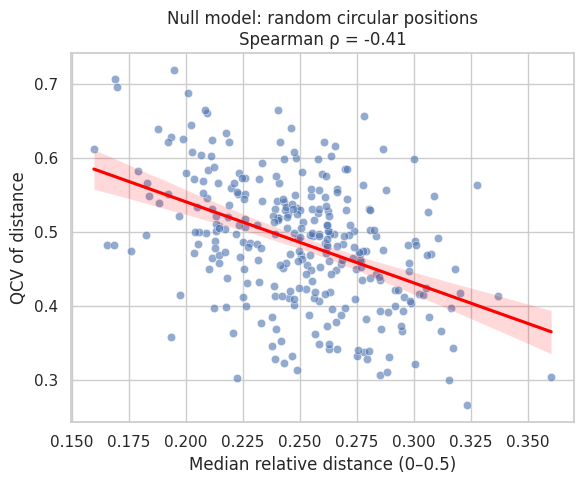

In [150]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# ============================================================
# CONFIG
# ============================================================

np.random.seed(42)

N_PAIRS = 300        # número de pares de replicones
N_PLASMIDS = 50      # número de plasmidos por par (co-ocurrencias)

# ============================================================
# FUNCIONES
# ============================================================

def circular_distance(a, b):
    """
    Distancia circular mínima en [0, 0.5]
    """
    d = np.abs(a - b)
    return np.minimum(d, 1 - d)

def compute_qcv(values):
    """
    QCV robusto basado en cuantiles
    """
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    if (q1 + q3) == 0:
        return np.nan
    return (q3 - q1) / (q3 + q1)

# ============================================================
# SIMULACIÓN
# ============================================================

results = []

for pair_id in range(N_PAIRS):
    
    distances = []
    
    for _ in range(N_PLASMIDS):
        # posiciones aleatorias en el círculo [0,1)
        pos1 = np.random.rand()
        pos2 = np.random.rand()
        
        d = circular_distance(pos1, pos2)
        distances.append(d)
    
    distances = np.array(distances)
    
    median_dist = np.median(distances)
    qcv = compute_qcv(distances)
    
    results.append({
        "pair": pair_id,
        "median_rel": median_dist,
        "QCV": qcv
    })

df = pd.DataFrame(results).dropna()

# ============================================================
# ANÁLISIS
# ============================================================

rho, pval = spearmanr(df["median_rel"], df["QCV"])

print(f"Spearman rho = {rho:.3f}, p = {pval:.3e}")

# ============================================================
# PLOT
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="median_rel", y="QCV", alpha=0.6)
sns.regplot(data=df, x="median_rel", y="QCV",
            scatter=False, color="red")

plt.xlabel("Median relative distance (0–0.5)")
plt.ylabel("QCV of distance")
plt.title(f"Null model: random circular positions\nSpearman ρ = {rho:.2f}")
plt.tight_layout()
plt.show()

Spearman rho = -0.664, p = 1.412e-39


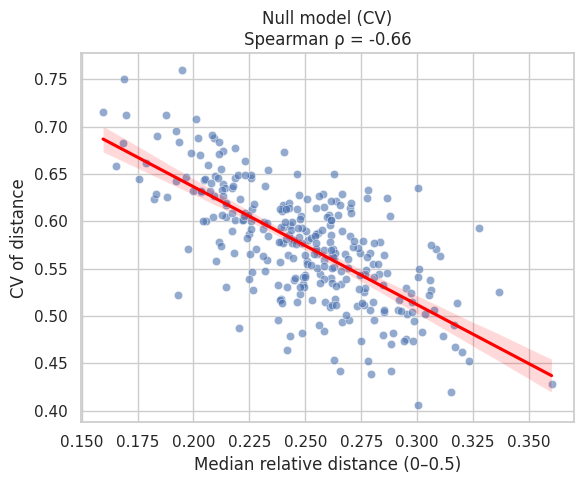

In [151]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# ============================================================
# CONFIG
# ============================================================

np.random.seed(42)

N_PAIRS = 300
N_PLASMIDS = 50

# ============================================================
# FUNCIONES
# ============================================================

def circular_distance(a, b):
    d = np.abs(a - b)
    return np.minimum(d, 1 - d)

def compute_cv(values):
    mean = np.mean(values)
    std = np.std(values)
    if mean == 0:
        return np.nan
    return std / mean

# ============================================================
# SIMULACIÓN
# ============================================================

results = []

for pair_id in range(N_PAIRS):
    
    distances = []
    
    for _ in range(N_PLASMIDS):
        pos1 = np.random.rand()
        pos2 = np.random.rand()
        
        d = circular_distance(pos1, pos2)
        distances.append(d)
    
    distances = np.array(distances)
    
    median_dist = np.median(distances)
    cv = compute_cv(distances)
    
    results.append({
        "pair": pair_id,
        "median_rel": median_dist,
        "CV": cv
    })

df = pd.DataFrame(results).dropna()

# ============================================================
# ANÁLISIS
# ============================================================

rho, pval = spearmanr(df["median_rel"], df["CV"])

print(f"Spearman rho = {rho:.3f}, p = {pval:.3e}")

# ============================================================
# PLOT
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="median_rel", y="CV", alpha=0.6)
sns.regplot(data=df, x="median_rel", y="CV",
            scatter=False, color="red")

plt.xlabel("Median relative distance (0–0.5)")
plt.ylabel("CV of distance")
plt.title(f"Null model (CV)\nSpearman ρ = {rho:.2f}")
plt.tight_layout()
plt.show()

In [140]:
# ============================================================
# MASTER TABLE OF ALL REPLICON-PAIR METRICS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. Helper: keep one row per rep_pair
# ------------------------------------------------------------

def ensure_unique(df, key="rep_pair", name="table"):
    dup = df[df.duplicated(key, keep=False)]
    if not dup.empty:
        print(f"[WARNING] {name} has duplicated {key} values: {dup[key].nunique()} duplicated pairs")
        print(dup.sort_values(key).head(10))
        df = df.drop_duplicates(subset=key).copy()
        print(f"[INFO] Keeping first occurrence for duplicated pairs in {name}")
    return df

# ------------------------------------------------------------
# 1. Extract relevant columns from each source table
# ------------------------------------------------------------

cointegration_sub = cointegration[[
    "rep_pair",
    "cointegration_rate"
]].copy()

rep_stats_sub = rep_stats.reset_index()[[
    "rep_pair",
    "median_abs",
    "median_rel",
    "QCV_abs",
    "QCV_rel"
]].copy()

mantel_sub = mantel[[
    "rep_pair",
    "mantel_r"
]].copy()

# Optional: if you have extra pair-level metrics, add them here
# Example:
# extra_sub = extra_table[["rep_pair", "some_metric"]].copy()

# ------------------------------------------------------------
# 2. Make sure each table has unique rep_pair
# ------------------------------------------------------------

cointegration_sub = ensure_unique(cointegration_sub, name="cointegration_sub")
rep_stats_sub     = ensure_unique(rep_stats_sub,     name="rep_stats_sub")
mantel_sub        = ensure_unique(mantel_sub,        name="mantel_sub")

# ------------------------------------------------------------
# 3. Outer merge = keep all pairs from all sources
# ------------------------------------------------------------

master_table = (
    cointegration_sub
    .merge(rep_stats_sub, on="rep_pair", how="outer")
    .merge(mantel_sub, on="rep_pair", how="outer")
    # .merge(extra_sub, on="rep_pair", how="outer")
)

# ------------------------------------------------------------
# 4. Split rep_pair into the two replicons
# ------------------------------------------------------------

rep_pair_str = master_table["rep_pair"].astype(str)

if rep_pair_str.str.contains("|", regex=False).any():
    split_df = rep_pair_str.str.split("|", expand=True, regex=False)
elif rep_pair_str.str.contains("__", regex=False).any():
    split_df = rep_pair_str.str.split("__", expand=True, regex=False)
elif rep_pair_str.str.contains(";", regex=False).any():
    split_df = rep_pair_str.str.split(";", expand=True, regex=False)
else:
    split_df = pd.DataFrame(index=master_table.index)
    print("[WARNING] Could not infer rep_pair separator automatically")

if split_df.shape[1] >= 2:
    master_table["rep1"] = split_df.iloc[:, 0]
    master_table["rep2"] = split_df.iloc[:, 1]
    if split_df.shape[1] > 2:
        print(f"[WARNING] rep_pair split produced {split_df.shape[1]} columns; keeping only first two")
else:
    master_table["rep1"] = np.nan
    master_table["rep2"] = np.nan
# 5. Useful summary columns
# ------------------------------------------------------------

metric_cols = [
    "cointegration_rate",
    "median_abs",
    "median_rel",
    "QCV_abs",
    "QCV_rel",
    "mantel_r"
]

master_table["n_available_metrics"] = master_table[metric_cols].notna().sum(axis=1)
master_table["has_cointegration"] = master_table["cointegration_rate"].notna()
master_table["has_distance"] = master_table[["median_abs", "median_rel"]].notna().any(axis=1)
master_table["has_qcv"] = master_table[["QCV_abs", "QCV_rel"]].notna().any(axis=1)
master_table["has_mantel"] = master_table["mantel_r"].notna()

# ------------------------------------------------------------
# 6. Optional categorisations for downstream analyses
# ------------------------------------------------------------

def coint_cat(x):
    if pd.isna(x):
        return np.nan
    elif x >= 0.8:
        return "HighCoint"
    elif x <= 0.2:
        return "LowCoint"
    else:
        return "MixedCoint"

master_table["cointegration_cat"] = master_table["cointegration_rate"].apply(coint_cat)

# distance categories based on median_abs
valid_dist = master_table["median_abs"].dropna()
if len(valid_dist) > 0:
    low_thr = valid_dist.quantile(0.25)
    high_thr = valid_dist.quantile(0.75)

    def dist_cat(x):
        if pd.isna(x):
            return np.nan
        elif x <= low_thr:
            return "LowDist"
        elif x >= high_thr:
            return "HighDist"
        else:
            return "MidDist"

    master_table["dist_cat"] = master_table["median_abs"].apply(dist_cat)

    print(f"Distance thresholds from median_abs:")
    print(f"  LowDist  <= {low_thr:.3f}")
    print(f"  HighDist >= {high_thr:.3f}")
else:
    master_table["dist_cat"] = np.nan

# ------------------------------------------------------------
# 7. Reorder columns
# ------------------------------------------------------------

ordered_cols = [
    "rep_pair", "rep1", "rep2",
    "cointegration_rate", "cointegration_cat",
    "median_abs", "median_rel", "dist_cat",
    "QCV_abs", "QCV_rel",
    "mantel_r",
    "n_available_metrics",
    "has_cointegration", "has_distance", "has_qcv", "has_mantel"
]

remaining_cols = [c for c in master_table.columns if c not in ordered_cols]
master_table = master_table[ordered_cols + remaining_cols]

# ------------------------------------------------------------
# 8. Inspect
# ------------------------------------------------------------

print("\nMASTER TABLE SHAPE:")
print(master_table.shape)

print("\nNON-NA COUNTS:")
print(master_table[metric_cols].notna().sum())

print("\nFIRST ROWS:")
print(master_table.head())

# ------------------------------------------------------------
# 9. Save
# ------------------------------------------------------------

out_path = "master_replicon_pair_table.tsv"
master_table.to_csv(out_path, sep="\t", index=False)
print(f"\nSaved: {out_path}")

[WARNING] rep_pair split produced 3 columns; keeping only first two
Distance thresholds from median_abs:
  LowDist  <= 6143.500
  HighDist >= 43527.000

MASTER TABLE SHAPE:
(2082, 16)

NON-NA COUNTS:
cointegration_rate    2047
median_abs             349
median_rel             349
QCV_abs                349
QCV_rel                349
mantel_r               104
dtype: int64

FIRST ROWS:
                                 rep_pair         rep1 rep2  \
0                Col(BS512) || Col(MG828)  Col(BS512)         
1                    Col(BS512) || Col156  Col(BS512)         
2  Col(BS512) || ColRNAI_rep_cluster_1987  Col(BS512)         
3                    Col(BS512) || ColpVC  Col(BS512)         
4                    Col(BS512) || IncFIA  Col(BS512)         

   cointegration_rate cointegration_cat  median_abs  median_rel dist_cat  \
0                 0.0          LowCoint         NaN         NaN      NaN   
1                 0.0          LowCoint         NaN         NaN      NaN   
2    

In [141]:
import os
os.getcwd()

'/home/nacho/HDD16/Nacho/RepliCOOC/derep/efficiency_vs_mantel'

Modes (bp): [  896.2 53008.3]
Main antimode (bp): 2305.7


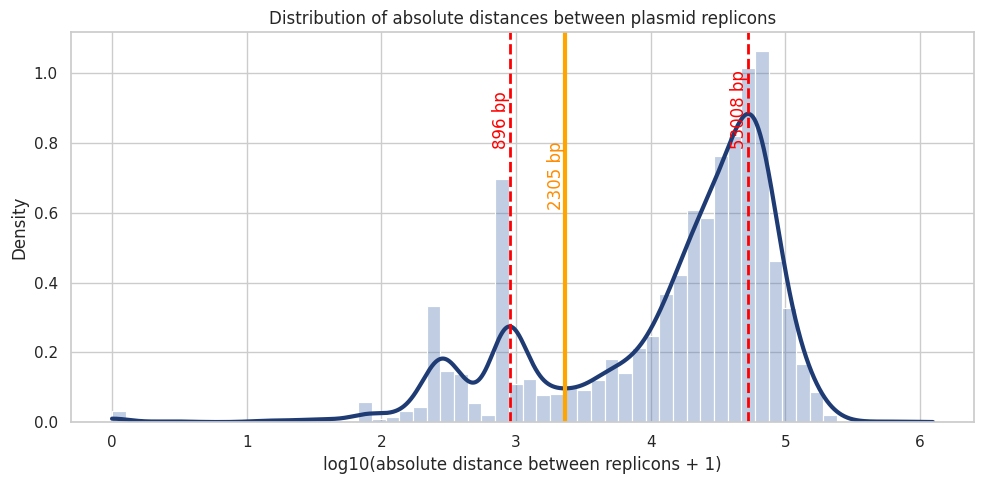

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
table_path = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/replicon_distances.tsv"
df = pd.read_csv(table_path, sep="\t")

x = df["distance_absolute"].dropna()
logx = np.log10(x + 1)

# ------------------------------------------------------------
# KDE estimation
# ------------------------------------------------------------
kde = gaussian_kde(logx, bw_method=0.15)

grid = np.linspace(logx.min(), logx.max(), 4000)
density = kde(grid)

# ------------------------------------------------------------
# Find peaks (modes)
# ------------------------------------------------------------
peaks, _ = find_peaks(density)

# select two highest peaks
top_peaks = peaks[np.argsort(density[peaks])[-2:]]
top_peaks = np.sort(top_peaks)

mode_logs = grid[top_peaks]
modes_bp = 10**mode_logs - 1

# ------------------------------------------------------------
# Find antimode between the two peaks
# ------------------------------------------------------------
valley_region = density[top_peaks[0]:top_peaks[1]]
antimode_index = np.argmin(valley_region) + top_peaks[0]

antimode_log = grid[antimode_index]
antimode_bp = 10**antimode_log - 1

print("Modes (bp):", np.round(modes_bp,1))
print("Main antimode (bp):", round(antimode_bp,1))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
sns.set_style("whitegrid")

plt.figure(figsize=(10,5))

# histogram
sns.histplot(
    logx,
    bins=60,
    stat="density",
    color="#4C72B0",
    alpha=0.35
)

# KDE curve
plt.plot(grid, density, color="#1f3b73", linewidth=3)

# dashed lines for modes
for m in mode_logs:
    plt.axvline(m, linestyle="--", color="red", linewidth=2)

# solid line for antimode
plt.axvline(antimode_log, color="orange", linewidth=3)

# labels
plt.text(mode_logs[0], max(density)*0.9, f"{int(modes_bp[0])} bp",
         rotation=90, color="red", ha="right")

plt.text(mode_logs[1], max(density)*0.9, f"{int(modes_bp[1])} bp",
         rotation=90, color="red", ha="right")

plt.text(antimode_log, max(density)*0.7, f"{int(antimode_bp)} bp",
         rotation=90, color="darkorange", ha="right")

plt.xlabel("log10(absolute distance between replicons + 1)")
plt.ylabel("Density")
plt.title("Distribution of absolute distances between plasmid replicons")

plt.tight_layout()
plt.show()

                             count      mean       std       min       25%  \
distance_class                                                               
Close replicons (<2.3 kb)     38.0  0.700928  0.343993  0.044118  0.370525   
Distant replicons (>2.3 kb)  278.0  0.450011  0.330256  0.003521  0.111111   

                                  50%       75%  max  
distance_class                                        
Close replicons (<2.3 kb)    0.891304  1.000000  1.0  
Distant replicons (>2.3 kb)  0.454545  0.732311  1.0  

Mann-Whitney U test
U = 7620.0
p = 9.600698589627396e-06


/tmp/ipykernel_2926773/134055477.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


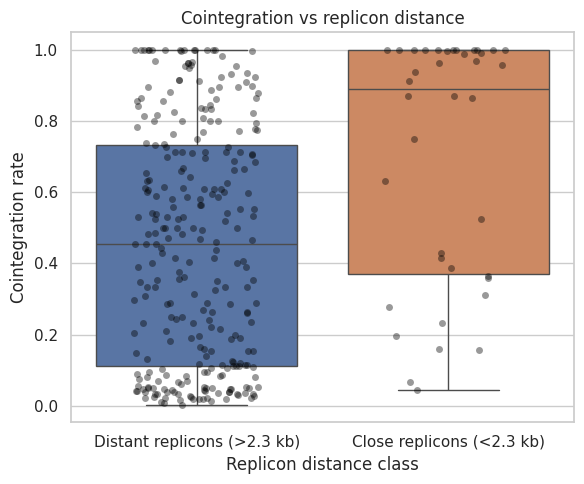

In [138]:
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Threshold from antimode
# ------------------------------------------------------------

threshold = 2300

df = struct_all.copy()

# classify pairs
df["distance_class"] = np.where(
    df["median_abs"] <= threshold,
    "Close replicons (<2.3 kb)",
    "Distant replicons (>2.3 kb)"
)

# remove NA
df = df.dropna(subset=["cointegration_rate", "median_abs"])

# ------------------------------------------------------------
# Descriptive stats
# ------------------------------------------------------------

summary = df.groupby("distance_class")["cointegration_rate"].describe()
print(summary)

# ------------------------------------------------------------
# Mann-Whitney test
# ------------------------------------------------------------

close_vals = df[df["distance_class"].str.contains("Close")]["cointegration_rate"]
far_vals = df[df["distance_class"].str.contains("Distant")]["cointegration_rate"]

stat, p = mannwhitneyu(close_vals, far_vals, alternative="two-sided")

print("\nMann-Whitney U test")
print("U =", stat)
print("p =", p)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

sns.set(style="whitegrid")

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="distance_class",
    y="cointegration_rate",
    palette=["#4C72B0", "#DD8452"]
)

sns.stripplot(
    data=df,
    x="distance_class",
    y="cointegration_rate",
    color="black",
    alpha=0.4,
    jitter=0.25
)

plt.ylabel("Cointegration rate")
plt.xlabel("Replicon distance class")
plt.title("Cointegration vs replicon distance")

plt.tight_layout()
plt.show()

Modes (relative distance): [0.009  0.4537]
Main antimode (relative distance): 0.0743


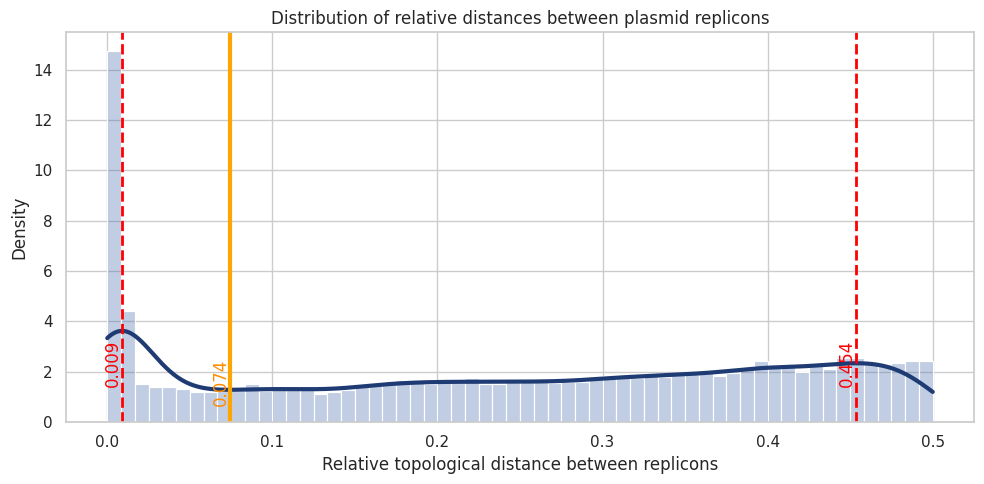


Summary:
                             count      mean       std       min       25%  \
distance_class                                                               
Close replicons (≤ 0.074)     45.0  0.736170  0.293612  0.068182  0.525974   
Distant replicons (> 0.074)  271.0  0.437678  0.330339  0.003521  0.107408   

                                  50%       75%  max  
distance_class                                        
Close replicons (≤ 0.074)    0.865169  1.000000  1.0  
Distant replicons (> 0.074)  0.407407  0.714286  1.0  

Mann-Whitney U test
Threshold (median_rel) = 0.0743
U = 9240.0
p = 3.074182940671227e-08


/tmp/ipykernel_2926773/3309795748.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


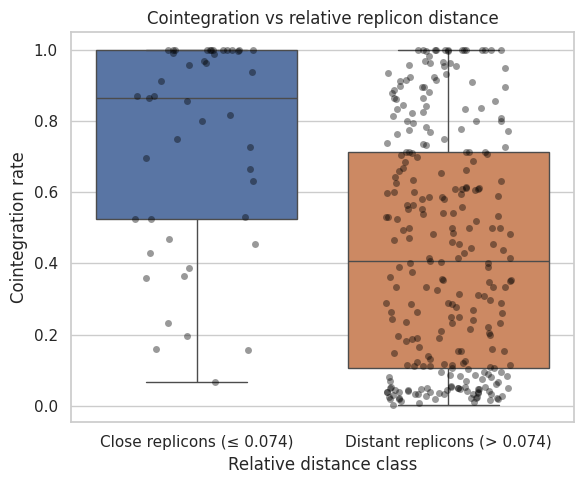

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde, mannwhitneyu
from scipy.signal import find_peaks

# ============================================================
# 1. KDE + antimode for RELATIVE distance
# ============================================================

table_path = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/replicon_distances.tsv"
dist_df = pd.read_csv(table_path, sep="\t")

# usar distancia relativa directamente
x = dist_df["distance_relative"].dropna()

# ------------------------------------------------------------
# KDE estimation
# ------------------------------------------------------------
kde = gaussian_kde(x, bw_method=0.12)

grid = np.linspace(x.min(), x.max(), 4000)
density = kde(grid)

# ------------------------------------------------------------
# Find peaks (modes)
# ------------------------------------------------------------
peaks, _ = find_peaks(density)

if len(peaks) < 2:
    raise ValueError("No se detectaron al menos dos picos en distance_relative. Prueba a ajustar bw_method.")

# seleccionar los dos picos más altos
top_peaks = peaks[np.argsort(density[peaks])[-2:]]
top_peaks = np.sort(top_peaks)

mode_vals = grid[top_peaks]

# ------------------------------------------------------------
# Find antimode between the two peaks
# ------------------------------------------------------------
valley_region = density[top_peaks[0]:top_peaks[1]]
antimode_index = np.argmin(valley_region) + top_peaks[0]

antimode_val = grid[antimode_index]

print("Modes (relative distance):", np.round(mode_vals, 4))
print("Main antimode (relative distance):", round(antimode_val, 4))

# ------------------------------------------------------------
# Plot distribution
# ------------------------------------------------------------
sns.set_style("whitegrid")

plt.figure(figsize=(10, 5))

sns.histplot(
    x,
    bins=60,
    stat="density",
    color="#4C72B0",
    alpha=0.35
)

plt.plot(grid, density, color="#1f3b73", linewidth=3)

# líneas de modos
for m in mode_vals:
    plt.axvline(m, linestyle="--", color="red", linewidth=2)

# línea de antimodo
plt.axvline(antimode_val, color="orange", linewidth=3)

# etiquetas
ylim_top = max(density)

plt.text(mode_vals[0], ylim_top * 0.9, f"{mode_vals[0]:.3f}",
         rotation=90, color="red", ha="right", va="top")

plt.text(mode_vals[1], ylim_top * 0.9, f"{mode_vals[1]:.3f}",
         rotation=90, color="red", ha="right", va="top")

plt.text(antimode_val, ylim_top * 0.7, f"{antimode_val:.3f}",
         rotation=90, color="darkorange", ha="right", va="top")

plt.xlabel("Relative topological distance between replicons")
plt.ylabel("Density")
plt.title("Distribution of relative distances between plasmid replicons")

plt.tight_layout()
plt.show()

# ============================================================
# 2. Boxplot: cointegration vs RELATIVE distance class
# ============================================================

# usar el antimodo encontrado
threshold_rel = antimode_val

df = struct_all.copy()

# quitar NA relevantes
df = df.dropna(subset=["cointegration_rate", "median_rel"]).copy()

# clasificar pares
df["distance_class"] = np.where(
    df["median_rel"] <= threshold_rel,
    f"Close replicons (≤ {threshold_rel:.3f})",
    f"Distant replicons (> {threshold_rel:.3f})"
)

# ------------------------------------------------------------
# Descriptive stats
# ------------------------------------------------------------
summary = df.groupby("distance_class")["cointegration_rate"].describe()
print("\nSummary:")
print(summary)

# ------------------------------------------------------------
# Mann-Whitney test
# ------------------------------------------------------------
close_vals = df.loc[df["median_rel"] <= threshold_rel, "cointegration_rate"]
far_vals   = df.loc[df["median_rel"] >  threshold_rel, "cointegration_rate"]

stat, p = mannwhitneyu(close_vals, far_vals, alternative="two-sided")

print("\nMann-Whitney U test")
print("Threshold (median_rel) =", round(threshold_rel, 4))
print("U =", stat)
print("p =", p)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
sns.set(style="whitegrid")

plt.figure(figsize=(6, 5))

order = [
    f"Close replicons (≤ {threshold_rel:.3f})",
    f"Distant replicons (> {threshold_rel:.3f})"
]

sns.boxplot(
    data=df,
    x="distance_class",
    y="cointegration_rate",
    order=order,
    palette=["#4C72B0", "#DD8452"]
)

sns.stripplot(
    data=df,
    x="distance_class",
    y="cointegration_rate",
    order=order,
    color="black",
    alpha=0.4,
    jitter=0.25
)

plt.ylabel("Cointegration rate")
plt.xlabel("Relative distance class")
plt.title("Cointegration vs relative replicon distance")

plt.tight_layout()
plt.show()

N: 349
count    349.000000
mean       0.364296
std        0.252910
min        0.000000
25%        0.168072
50%        0.327708
75%        0.505282
max        1.000000
Name: QCV_abs, dtype: float64


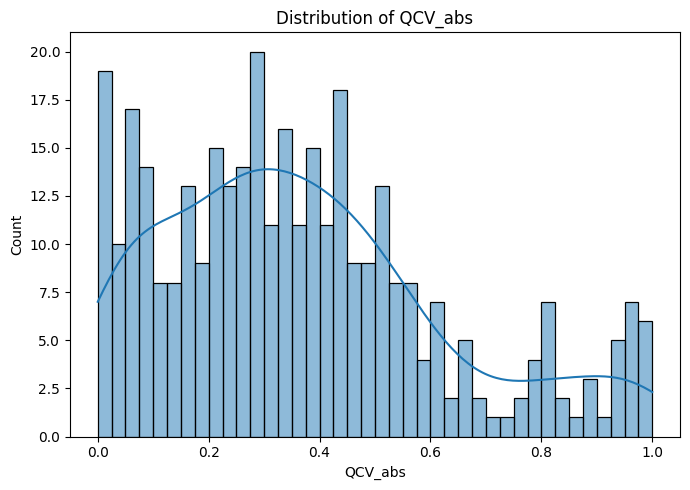

In [125]:
# ------------------------------------------------------------
# Distribution of QCV_abs
# ------------------------------------------------------------

qcv = struct_all["QCV_abs"].dropna()

print("N:", len(qcv))
print(qcv.describe())

plt.figure(figsize=(7,5))

sns.histplot(
    qcv,
    bins=40,
    kde=True
)

plt.xlabel("QCV_abs")
plt.ylabel("Count")
plt.title("Distribution of QCV_abs")
plt.tight_layout()
plt.show()

In [124]:
# ============================================================
# IncF-IncF ENRICHMENT ANALYSIS (CORRECTED)
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact

# ------------------------------------------------------------
# 1. Detect IncF–IncF pairs
# ------------------------------------------------------------

def is_incF_pair(pair):

    if pd.isna(pair):
        return False

    reps = [x.strip() for x in pair.split("||")]

    if len(reps) != 2:
        return False

    return reps[0].startswith("IncF") and reps[1].startswith("IncF")


struct_all["IncF_pair"] = struct_all["rep_pair"].apply(is_incF_pair)

print("IncF–IncF pairs detected:", struct_all["IncF_pair"].sum())

# ------------------------------------------------------------
# 2. Cointegration categories
# ------------------------------------------------------------

def cointegration_category(x):

    if pd.isna(x):
        return np.nan
    elif x >= 0.8:
        return "strong_cointegration"
    elif x <= 0.2:
        return "strong_repulsion"
    else:
        return "mixed"

struct_all["cointegration_cat"] = struct_all["cointegration_rate"].apply(cointegration_category)

# ------------------------------------------------------------
# 3. Structural proximity
# ------------------------------------------------------------

struct_all["close_structure"] = struct_all["median_rel"] < 0.1

# ------------------------------------------------------------
# 4. Fisher enrichment
# ------------------------------------------------------------

def enrichment_test(df, condition_col, condition_value):

    subset = df[df[condition_col].notna()].copy()

    inside = subset[condition_col] == condition_value

    a = ((subset["IncF_pair"]) & inside).sum()
    b = ((~subset["IncF_pair"]) & inside).sum()
    c = ((subset["IncF_pair"]) & (~inside)).sum()
    d = ((~subset["IncF_pair"]) & (~inside)).sum()

    table = [[a, c],
             [b, d]]

    odds, p = fisher_exact(table)

    print("\n====================================")
    print("Condition:", condition_value)

    cont = pd.DataFrame(
        table,
        index=["IncF–IncF pairs", "other pairs"],
        columns=["inside", "outside"]
    )

    print("\nContingency table:")
    print(cont)

    print("\nTotal rows analysed:", len(subset))
    print("Total IncF–IncF in subset:", subset["IncF_pair"].sum())

    print("\nOdds ratio:", odds)
    print("p-value:", "{:.3e}".format(p))


# ------------------------------------------------------------
# 5. Run tests
# ------------------------------------------------------------

enrichment_test(struct_all, "cointegration_cat", "strong_cointegration")
enrichment_test(struct_all, "cointegration_cat", "strong_repulsion")
enrichment_test(struct_all, "close_structure", True)

IncF–IncF pairs detected: 10

Condition: strong_cointegration

Contingency table:
                 inside  outside
IncF–IncF pairs       3        3
other pairs         108     1933

Total rows analysed: 2047
Total IncF–IncF in subset: 6

Odds ratio: 17.89814814814815
p-value: 2.754e-03

Condition: strong_repulsion

Contingency table:
                 inside  outside
IncF–IncF pairs       0        6
other pairs        1695      346

Total rows analysed: 2047
Total IncF–IncF in subset: 6

Odds ratio: 0.0
p-value: 2.495e-05

Condition: True

Contingency table:
                 inside  outside
IncF–IncF pairs       1        9
other pairs          70     2002

Total rows analysed: 2082
Total IncF–IncF in subset: 10

Odds ratio: 3.1777777777777776
p-value: 2.937e-01


In [123]:
struct_all.loc[struct_all["IncF_pair"]]

,rep_pair,cointegration_rate,median_abs,median_rel,QCV_abs,QCV_rel,mantel_r,IncF_pair,cointegration_cat,close_structure
399,IncFIA || IncFIA,NaN,46345.5,0.380780,0.347893,0.233031,NaN,True,NaN,False
400,IncFIA || IncFIB,0.685523,38973.0,0.335219,0.432017,0.345370,0.428794,True,mixed,False
401,IncFIA || IncFIC,0.963255,855.0,0.007972,0.930452,0.905807,0.183027,True,strong_cointegration,True
402,IncFIA || IncFII,0.833333,12152.0,0.122528,0.964751,0.969266,0.254829,True,strong_cointegration,False
461,IncFIB || IncFIB,NaN,59661.5,0.305113,0.802077,0.486781,NaN,True,NaN,False
462,IncFIB || IncFIC,0.878125,40613.5,0.357348,0.987870,0.976151,0.190731,True,strong_cointegration,False
463,IncFIB || IncFII,0.794069,47282.0,0.327571,0.437677,0.333197,0.194672,True,mixed,False
537,IncFIC || IncFIC,NaN,64488.0,0.289058,0.435230,0.267904,NaN,True,NaN,False
538,IncFIC || IncFII,0.559322,33876.0,0.281606,0.956725,0.905763,0.236317,True,mixed,False
594,IncFII || IncFII,NaN,38116.0,0.293618,0.546609,0.678442,NaN,True,NaN,False


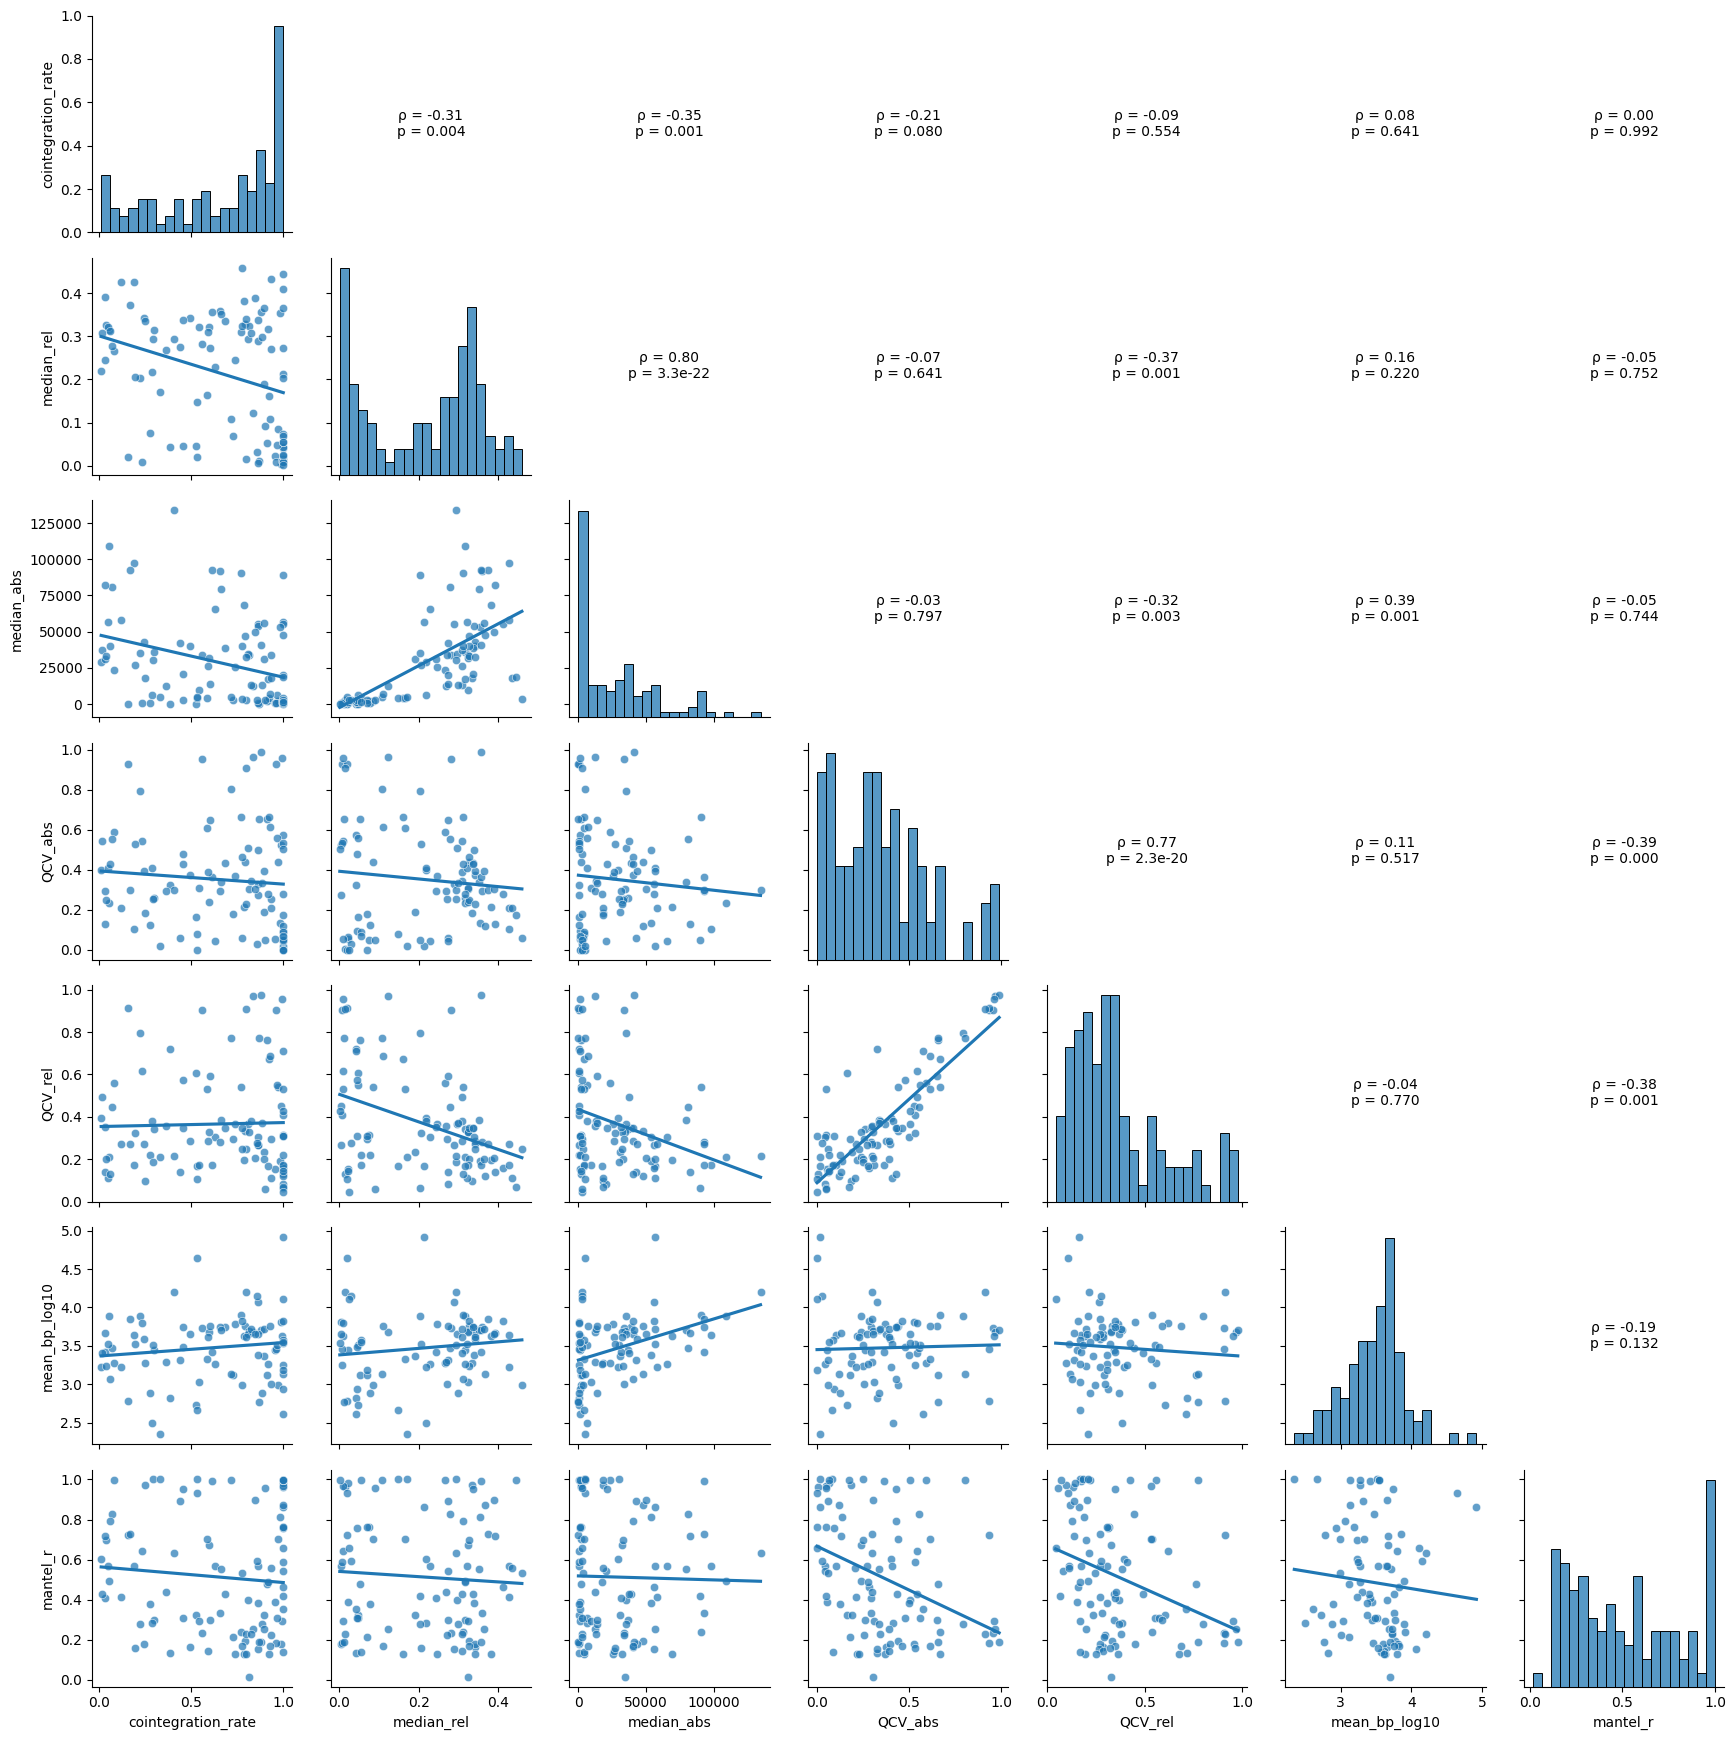

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Variables
# ------------------------------------------------------------

vars_of_interest = [
    "cointegration_rate",
    "median_rel","median_abs","QCV_abs","QCV_rel",
    "mean_bp_log10","mantel_r"
]

df = merged[vars_of_interest].copy()

# ------------------------------------------------------------
# Compute all Spearman tests (for FDR)
# ------------------------------------------------------------

pairs = []
pvals = []

for i in range(len(vars_of_interest)):
    for j in range(i+1, len(vars_of_interest)):
        v1 = vars_of_interest[i]
        v2 = vars_of_interest[j]
        mask = df[v1].notna() & df[v2].notna()
        
        if mask.sum() >= 5:
            rho, p = spearmanr(df.loc[mask, v1], df.loc[mask, v2])
        else:
            rho, p = np.nan, np.nan
        
        pairs.append((v1, v2, rho, p))
        pvals.append(p)

# FDR correction
_, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

# Store results in dictionary
stats_dict = {}
for idx, (v1, v2, rho, _) in enumerate(pairs):
    stats_dict[(v1, v2)] = (rho, pvals_fdr[idx])
    stats_dict[(v2, v1)] = (rho, pvals_fdr[idx])  # symmetric

# ------------------------------------------------------------
# Custom upper panel function
# ------------------------------------------------------------

def corrfunc(x, y, **kws):
    ax = plt.gca()
    v1 = x.name
    v2 = y.name
    
    rho, p = stats_dict.get((v1, v2), (np.nan, np.nan))
    
    if np.isnan(rho):
        text = "NA"
    else:
        if p < 1e-4:
            p_text = f"{p:.1e}"
        else:
            p_text = f"{p:.3f}"
        text = f"ρ = {rho:.2f}\np = {p_text}"
    
    ax.annotate(
        text,
        xy=(0.5, 0.5),
        xycoords='axes fraction',
        ha='center',
        va='center',
        fontsize=10
    )
    ax.set_axis_off()

# ------------------------------------------------------------
# Build PairGrid
# ------------------------------------------------------------

g = sns.PairGrid(df, vars=vars_of_interest, diag_sharey=False)

g.map_lower(sns.scatterplot, alpha=0.7)
g.map_lower(sns.regplot, scatter=False, ci=None)

g.map_diag(sns.histplot, bins=20, kde=False)

g.map_upper(corrfunc)

plt.tight_layout()
plt.show()

Pairs retained: 101

Counts per category:
category
LowDist_HighCoint     23
HighDist_HighCoint     3
HighDist_LowCoint      2
LowDist_LowCoint       1
Name: count, dtype: int64

Pairwise Mann–Whitney tests


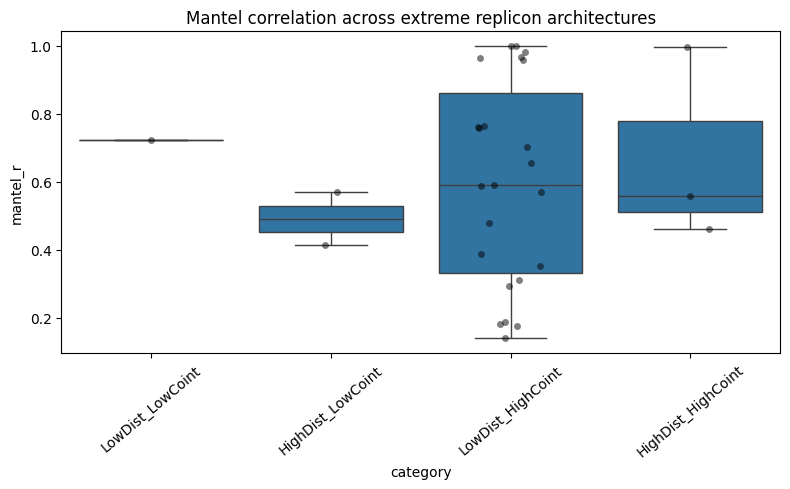

In [113]:
# ============================================================
# EXTREME CATEGORY ANALYSIS
# distance_rel + cointegration_rate
# ============================================================

from scipy.stats import kruskal, mannwhitneyu
import itertools

df = struct_all[
    ["rep_pair", "median_rel", "cointegration_rate", "mantel_r"]
].dropna().copy()

print("Pairs retained:", df.shape[0])

# ------------------------------------------------------------
# 1. Build extreme categories
# ------------------------------------------------------------

def classify(row):

    d = row["median_rel"]
    c = row["cointegration_rate"]

    if d < 0.1 and c > 0.8:
        return "LowDist_HighCoint"

    if d < 0.1 and c < 0.2:
        return "LowDist_LowCoint"

    if d > 0.4 and c > 0.8:
        return "HighDist_HighCoint"

    if d > 0.4 and c < 0.2:
        return "HighDist_LowCoint"

    return None


df["category"] = df.apply(classify, axis=1)
df = df.dropna()

print("\nCounts per category:")
print(df["category"].value_counts())

# ------------------------------------------------------------
# 2. Global test
# ------------------------------------------------------------

groups = [g["mantel_r"].values
          for _, g in df.groupby("category")
          if len(g) >= 5]

if len(groups) > 1:
    stat, p = kruskal(*groups)
    print("\nKruskal-Wallis test:")
    print("H =", stat, "p =", p)

# ------------------------------------------------------------
# 3. Pairwise tests
# ------------------------------------------------------------

print("\nPairwise Mann–Whitney tests")

cats = df["category"].unique()

for c1, c2 in itertools.combinations(cats, 2):

    x = df[df["category"] == c1]["mantel_r"]
    y = df[df["category"] == c2]["mantel_r"]

    if len(x) >= 5 and len(y) >= 5:

        stat, p = mannwhitneyu(x, y)

        print(f"{c1} vs {c2} | p={p:.4e}")

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="category", y="mantel_r")
sns.stripplot(data=df, x="category", y="mantel_r",
              color="black", alpha=0.5, jitter=0.2)

plt.title("Mantel correlation across extreme replicon architectures")
plt.xticks(rotation=40)

plt.tight_layout()
plt.show()

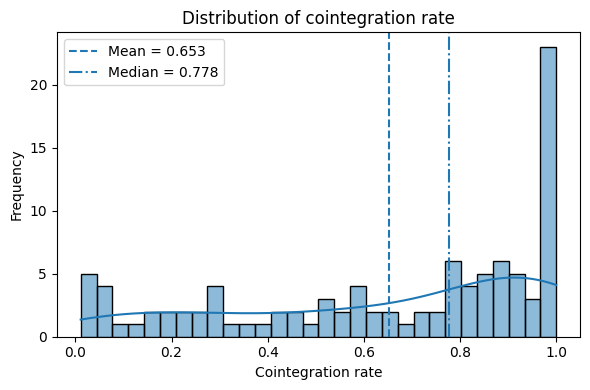

N = 101
Mean = 0.6529
Median = 0.7778
SD = 0.3288


In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extraer variable
x = merged["cointegration_rate"].dropna()

# Estadísticos básicos
mean_val = x.mean()
median_val = x.median()

plt.figure(figsize=(6,4))

sns.histplot(x, bins=30, kde=True)

plt.axvline(mean_val, linestyle="--", label=f"Mean = {mean_val:.3f}")
plt.axvline(median_val, linestyle="-.", label=f"Median = {median_val:.3f}")

plt.xlabel("Cointegration rate")
plt.ylabel("Frequency")
plt.title("Distribution of cointegration rate")
plt.legend()

plt.tight_layout()
plt.show()

print(f"N = {len(x)}")
print(f"Mean = {mean_val:.4f}")
print(f"Median = {median_val:.4f}")
print(f"SD = {x.std():.4f}")

In [88]:
# Seleccionar columnas
table = merged[["rep_pair_fixed", "cointegration_rate"]].copy()

# Eliminar NA si quieres solo valores válidos
table = table.dropna(subset=["cointegration_rate"])

# Ordenar opcionalmente (por ejemplo, de mayor a menor)
table = table.sort_values("cointegration_rate", ascending=False)

# Reset index limpio
table = table.reset_index(drop=True)

# Mostrar
table.head()

print(f"N pairs = {len(table)}")

N pairs = 101


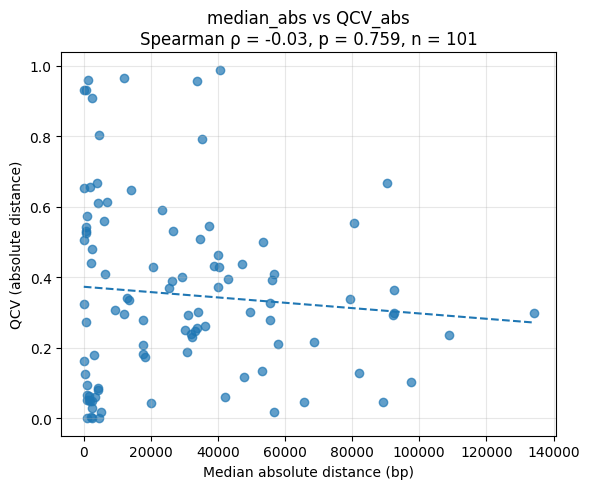

In [10]:
# ============================================================
# SCATTER: median_abs vs QCV_abs
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from scipy.stats import linregress

x = merged["median_abs"]
y = merged["QCV_abs"]

mask = x.notna() & y.notna()

x = x[mask]
y = y[mask]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.7)

# Spearman correlation
if len(x) >= 5:
    rho, p = spearmanr(x, y)
    
    # Trend line (OLS, solo visual)
    slope, intercept, r_lin, p_lin, _ = linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 200)
    plt.plot(xs, intercept + slope*xs, linestyle="--")
    
    plt.title(f"median_abs vs QCV_abs\nSpearman ρ = {rho:.2f}, p = {p:.3g}, n = {len(x)}")
else:
    plt.title("Not enough data")

plt.xlabel("Median absolute distance (bp)")
plt.ylabel("QCV (absolute distance)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


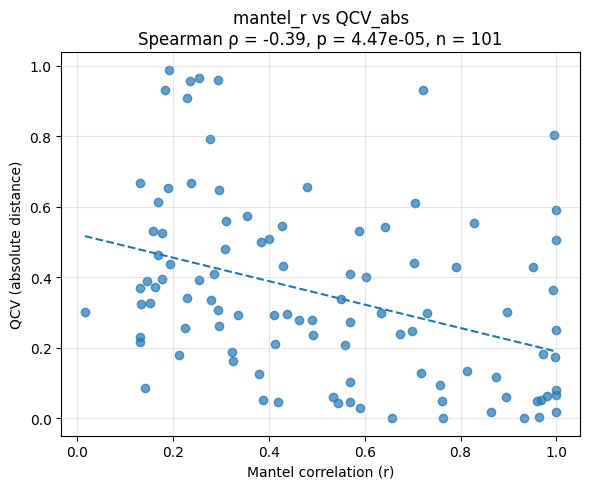

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from scipy.stats import linregress

x = merged["mantel_r"]
y = merged["QCV_abs"]

mask = x.notna() & y.notna()

x = x[mask]
y = y[mask]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.7)

# Spearman correlation
if len(x) >= 5:
    rho, p = spearmanr(x, y)
    
    # Trend line (solo visual)
    slope, intercept, r_lin, p_lin, _ = linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 200)
    plt.plot(xs, intercept + slope*xs, linestyle="--")
    
    plt.title(
        f"mantel_r vs QCV_abs\n"
        f"Spearman ρ = {rho:.2f}, p = {p:.3g}, n = {len(x)}"
    )
else:
    plt.title("Not enough data")

plt.xlabel("Mantel correlation (r)")
plt.ylabel("QCV (absolute distance)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# ADD mean_bp_log10 TO merged
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load homology table
# ------------------------------------------------------------

hom = pd.read_csv(
    "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing/replicon_pair_homology_full.tsv",
    sep="\t"
)

# Keep valid rows (igual que tu código original)
hom = hom.dropna(subset=["mean_bp"])

# Log-transform exactamente igual que antes
hom["mean_bp_log10"] = np.log10(hom["mean_bp"] + 1)

# ------------------------------------------------------------
# 2. Create same pair key format as in rep_stats
# ------------------------------------------------------------

# En tu dataset de distancias usaste:
# "rep1 || rep2" ordenado alfabéticamente

hom["rep_pair"] = hom.apply(
    lambda r: " || ".join(sorted([str(r["repA"]), str(r["repB"])])),
    axis=1
)

# ------------------------------------------------------------
# 3. Merge into merged
# ------------------------------------------------------------

merged = merged.merge(
    hom[["rep_pair", "mean_bp", "mean_bp_log10"]],
    on="rep_pair",
    how="left"
)

# ------------------------------------------------------------
# 4. Verificación
# ------------------------------------------------------------

print("Homology integrated:",
      merged["mean_bp_log10"].notna().sum(),
      "/",
      len(merged))

merged.head()


Homology integrated: 90 / 101


,repA,repB,n_same_cell,n_cell_same_plasmid,cointegration_rate,ci_low,ci_high,category,rep_pair,n,median_abs,median_rel,MAD_abs,MAD_rel,QCV_abs,QCV_rel,mantel_r,mean_bp,mean_bp_log10
0,IncFIB,IncFII,3035,2410,0.794069,0.779238,0.808332,MIXED,IncFIB || IncFII,1291,47282.0,0.327571,21743.0,0.104733,0.437677,0.333197,0.194672,5795.242947,3.763147
1,IncFIB,rep_cluster_2183,1051,825,0.784967,0.758872,0.809455,MIXED,IncFIB || rep_cluster_2183,365,68634.0,0.382861,15136.0,0.070190,0.215948,0.195834,0.131634,4220.883150,3.625506
2,IncFII,IncR,776,383,0.493557,0.457818,0.529345,MIXED,IncFII || IncR,214,40072.0,0.342509,15407.5,0.092587,0.372831,0.286323,0.162638,4540.231538,3.657174
3,IncFII,rep_cluster_2183,1139,1126,0.988586,0.980562,0.993909,STRONG_COINTEGRATION,IncFII || rep_cluster_2183,656,862.0,0.003931,6.0,0.001760,0.524315,0.451653,0.177041,6546.189035,3.816055
4,IncR,rep_cluster_2183,370,90,0.243243,0.200382,0.290266,MIXED,IncR || rep_cluster_2183,98,42960.0,0.342124,18335.0,0.085763,0.394378,0.273047,0.177899,3933.505229,3.594890


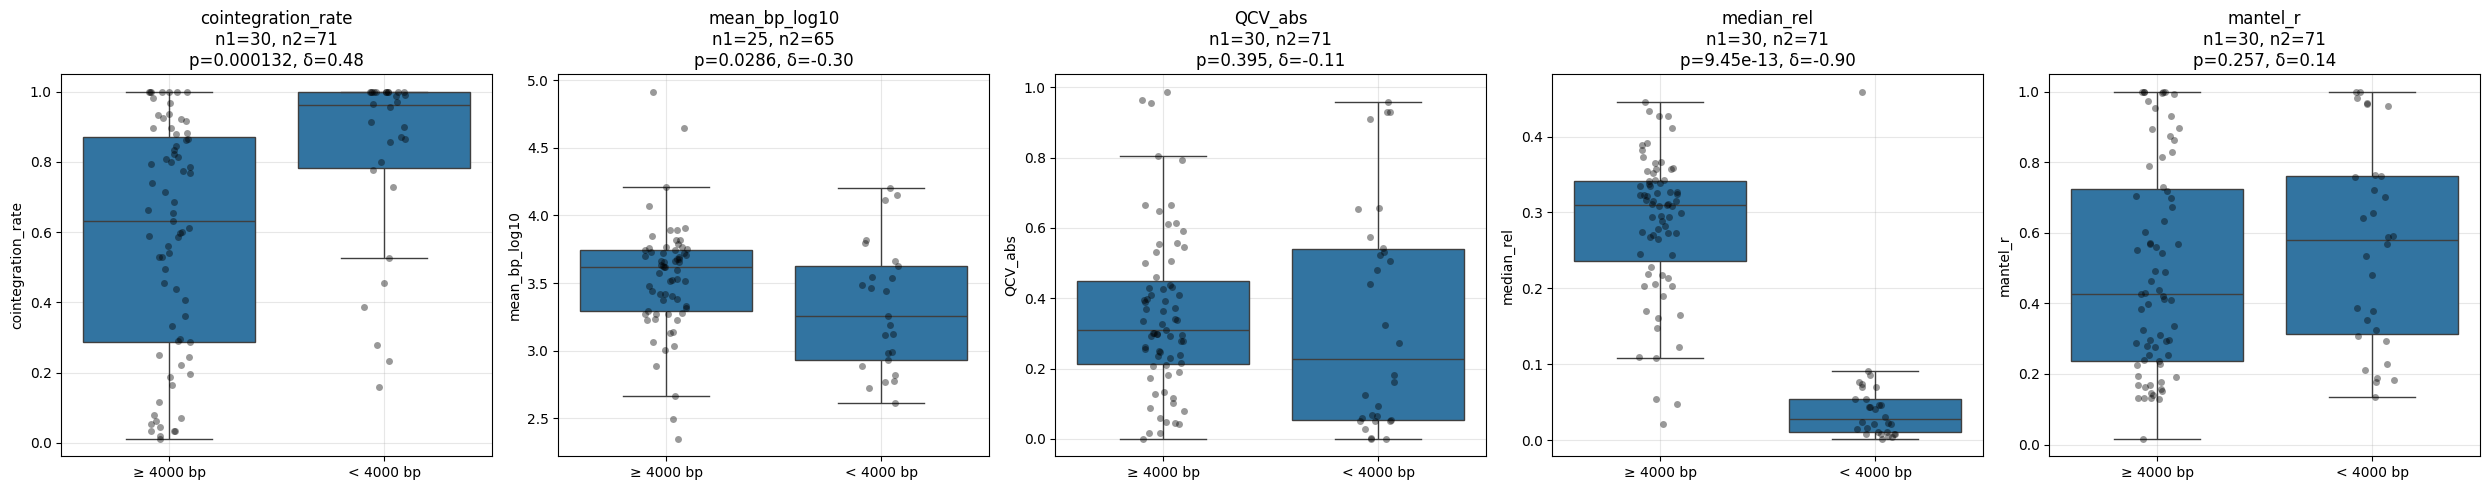

In [12]:
# ============================================================
# BOXPLOTS: median_abs < 4000 vs ≥ 4000
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

threshold = 4000

merged["distance_group"] = np.where(
    merged["median_abs"] < threshold,
    "< 4000 bp",
    "≥ 4000 bp"
)

variables = [
    "cointegration_rate",
    "mean_bp_log10",
    "QCV_abs",
    "median_rel","mantel_r"
]

# ------------------------------------------------------------
# Cliff's delta
# ------------------------------------------------------------

def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)
    gt = sum(xi > yi for xi in x for yi in y)
    lt = sum(xi < yi for xi in x for yi in y)
    return (gt - lt) / (nx * ny)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, len(variables), figsize=(5*len(variables), 5))

for ax, var in zip(axes, variables):
    
    sub = merged[["distance_group", var]].dropna()
    
    sns.boxplot(
        data=sub,
        x="distance_group",
        y=var,
        showfliers=False,
        ax=ax
    )
    
    sns.stripplot(
        data=sub,
        x="distance_group",
        y=var,
        color="black",
        alpha=0.4,
        ax=ax
    )
    
    g1 = sub[sub["distance_group"] == "< 4000 bp"][var]
    g2 = sub[sub["distance_group"] == "≥ 4000 bp"][var]
    
    n1 = len(g1)
    n2 = len(g2)
    
    if n1 > 4 and n2 > 4:
        u, p = mannwhitneyu(g1, g2, alternative="two-sided")
        delta = cliffs_delta(g1.values, g2.values)
        
        ax.set_title(
            f"{var}\n"
            f"n1={n1}, n2={n2}\n"
            f"p={p:.3g}, δ={delta:.2f}"
        )
    else:
        ax.set_title(f"{var}\n(n too small)")
    
    ax.set_xlabel("")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# TABLE: shared bases per pair + distance group
# ============================================================

threshold = 4000

merged["distance_group"] = np.where(
    merged["median_abs"] < threshold,
    "< 4000 bp",
    "≥ 4000 bp"
)

table_pairs = merged[
    ["rep_pair", "median_abs", "distance_group",
     "mean_bp", "mean_bp_log10"]
].copy()

table_pairs = table_pairs.sort_values("median_abs")

print(table_pairs.to_string(index=False))


                                    rep_pair  median_abs distance_group      mean_bp  mean_bp_log10
        rep_cluster_2350 || rep_cluster_2370        78.0      < 4000 bp   586.505371       2.769012
ColRNAI_rep_cluster_1987 || rep_cluster_2373       135.0      < 4000 bp   597.650623       2.777173
ColRNAI_rep_cluster_1987 || rep_cluster_2358       202.0      < 4000 bp   657.709480       2.818694
        rep_cluster_2335 || rep_cluster_2358       214.0      < 4000 bp   528.637250       2.723979
                  IncFIC || rep_cluster_2203       287.0      < 4000 bp  3450.000000       3.537945
        rep_cluster_2350 || rep_cluster_2358       422.5      < 4000 bp   771.603323       2.887957
                  IncFII || rep_cluster_2203       847.0      < 4000 bp  1789.272727       3.252919
                            IncFIA || IncFIC       855.0      < 4000 bp  2904.306942       3.463192
                  IncFIC || rep_cluster_2183       861.0      < 4000 bp  6269.902516       3.797330


In [14]:
import os
import re
import csv
import pandas as pd

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
NUCMER_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer"
GRAPH_DIR = os.path.join(NUCMER_DIR, "graph_cov90_noclose")
CONTAINMENT_FILE = os.path.join(GRAPH_DIR, "containment_NUC_levelup_strictlen.tsv")

REPLICON_MAP = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/plasmid_replicons.tsv"

WINDOW = 2000
RESULT_DIR = os.path.join(BASE_DIR, f"FULL_hyper_{WINDOW}")

# ============================================================
# Load replicon mapping
# ============================================================

df_rep = pd.read_csv(REPLICON_MAP, sep="\t")

rep_map = dict(
    zip(df_rep["plasmid_id"], df_rep["replicon_types"])
)

# ============================================================
# Reconstruct breakpoints in same order
# ============================================================

def parse_cov90_line(line):
    toks = re.split(r'\s+', line.strip())
    if len(toks) < 14:
        return None
    return {
        "s1": int(toks[0]),
        "e1": int(toks[1]),
        "s2": int(toks[2]),
        "e2": int(toks[3]),
        "lenR": int(toks[7]),
        "lenQ": int(toks[8]),
        "ref": toks[11],
        "qry": toks[12]
    }

breakpoints = []

with open(CONTAINMENT_FILE) as f:
    rdr = csv.DictReader(f, delimiter="\t")
    for row in rdr:

        big_len = int(row["big_len"])
        cov_path = os.path.join(NUCMER_DIR, row["source_file"])
        if not os.path.exists(cov_path):
            continue

        with open(cov_path) as fh:
            for line in fh:
                parsed = parse_cov90_line(line)
                if not parsed:
                    continue

                if parsed["lenR"] == big_len:
                    big = parsed["ref"]
                    small = parsed["qry"]

                elif parsed["lenQ"] == big_len:
                    big = parsed["qry"]
                    small = parsed["ref"]
                else:
                    continue

                breakpoints.append((big, small))
                breakpoints.append((big, small))
                break

print("Total breakpoints:", len(breakpoints))

# ============================================================
# Build breakpoint-level table
# ============================================================

rows = []

for i, (big, small) in enumerate(breakpoints):

    csv_file = os.path.join(RESULT_DIR, f"bp_{i}.csv")

    IS_present = 0

    if os.path.exists(csv_file) and os.path.getsize(csv_file) > 50:
        try:
            df = pd.read_csv(csv_file, sep=",", comment="#")
            if df.shape[0] > 0:
                IS_present = 1
        except:
            pass

    rows.append({
        "big_plasmid": big,
        "small_plasmid": small,
        "big_replicon": rep_map.get(big, "NA"),
        "small_replicon": rep_map.get(small, "NA"),
        "IS_present": IS_present
    })

df_bp = pd.DataFrame(rows)

df_bp.to_csv("breakpoint_level_with_replicons.tsv",
             sep="\t", index=False)

print("Breakpoint-level table written.")

# ============================================================
# Aggregate by replicon pair
# ============================================================

df_bp["pair"] = df_bp.apply(
    lambda x: " × ".join(sorted([
        x["big_replicon"],
        x["small_replicon"]
    ])),
    axis=1
)

pair_stats = (
    df_bp
    .groupby("pair")
    .agg(
        n_breakpoints=("IS_present","size"),
        n_IS=("IS_present","sum")
    )
    .reset_index()
)

pair_stats["IS_prevalence"] = (
    pair_stats["n_IS"] /
    pair_stats["n_breakpoints"]
)

pair_stats.to_csv("replicon_pair_IS_summary.tsv",
                  sep="\t", index=False)

print("Pair-level summary written.")

Total breakpoints: 3234
Breakpoint-level table written.
Pair-level summary written.


In [91]:
import os
import re
import csv
import pandas as pd

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
NUCMER_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer"
GRAPH_DIR = os.path.join(NUCMER_DIR, "graph_cov90_noclose")
CONTAINMENT_FILE = os.path.join(GRAPH_DIR, "containment_NUC_levelup_strictlen.tsv")

WINDOW = 2000
RESULT_DIR = os.path.join(BASE_DIR, f"FULL_hyper_{WINDOW}")

# ============================================================
# Parse cov90 to reconstruct events
# ============================================================

def parse_cov90_line(line):
    toks = re.split(r'\s+', line.strip())
    if len(toks) < 14:
        return None
    return {
        "lenR": int(toks[7]),
        "lenQ": int(toks[8]),
        "ref": toks[11],
        "qry": toks[12]
    }

events = []

with open(CONTAINMENT_FILE) as f:
    rdr = csv.DictReader(f, delimiter="\t")
    for row in rdr:

        big_len = int(row["big_len"])
        cov_path = os.path.join(NUCMER_DIR, row["source_file"])
        if not os.path.exists(cov_path):
            continue

        with open(cov_path) as fh:
            for line in fh:
                parsed = parse_cov90_line(line)
                if not parsed:
                    continue

                if parsed["lenR"] == big_len:
                    big = parsed["ref"]
                    small = parsed["qry"]
                elif parsed["lenQ"] == big_len:
                    big = parsed["qry"]
                    small = parsed["ref"]
                else:
                    continue

                events.append((big, small))
                break

print("Total events:", len(events))

# ============================================================
# Extract IS info
# ============================================================

def extract_IS_info(path):

    if not os.path.exists(path) or os.path.getsize(path) < 50:
        return "NA", "NA", 0

    try:
        df = pd.read_csv(path, sep=",", comment="#")

        if df.shape[0] == 0:
            return "NA", "NA", 0

        names = ";".join(df["name"].astype(str).unique())
        types = ";".join(df["type"].astype(str).unique())

        return names, types, 1

    except:
        return "NA", "NA", 0

# ============================================================
# Build event-level table
# ============================================================

rows = []

for event_id, (big, small) in enumerate(events):

    bp1_file = os.path.join(RESULT_DIR, f"bp_{2*event_id}.csv")
    bp2_file = os.path.join(RESULT_DIR, f"bp_{2*event_id+1}.csv")

    bp1_name, bp1_type, bp1_present = extract_IS_info(bp1_file)
    bp2_name, bp2_type, bp2_present = extract_IS_info(bp2_file)

    rows.append({
        "big_plasmid": big,
        "small_plasmid": small,

        "bp1_IS_names": bp1_name,
        "bp1_IS_type": bp1_type,
        "bp1_IS_present": bp1_present,

        "bp2_IS_names": bp2_name,
        "bp2_IS_type": bp2_type,
        "bp2_IS_present": bp2_present
    })

df_event = pd.DataFrame(rows)

df_event.to_csv("plasmid_event_IS_identity_full.tsv",
                sep="\t", index=False)

print("Event-level IS identity table written.")

Total events: 1617
Event-level IS identity table written.


In [15]:
pair_stats = pd.read_csv("replicon_pair_IS_summary.tsv", sep="\t")

# asegúrate de que la columna se llama igual
pair_stats = pair_stats.rename(columns={"pair": "rep_pair"})

merged = merged.merge(
    pair_stats[["rep_pair", "IS_prevalence", "n_breakpoints"]],
    on="rep_pair",
    how="left"
)

In [16]:
merged1 = merged[merged["n_breakpoints"] >= 0]

In [19]:
pair_stats

,rep_pair,n_breakpoints,n_IS,IS_prevalence
0,"Col(BS512) × Col(BS512),IncFIB",2,2,1.0
1,"Col(MG828) × Col(MG828),IncK2/Z",2,0,0.0
2,"Col(MG828),rep_cluster_2350 × rep_cluster_2350",22,0,0.0
3,"Col(MP18) × Col(MP18),rep_cluster_2350",6,0,0.0
4,"Col(VCM04),IncQ1 × IncQ1",4,4,1.0
...,...,...,...,...
574,"rep_cluster_889 × rep_cluster_889,rep_cluster_889",6,0,0.0
575,"rep_cluster_889 × rep_cluster_889,rep_cluster_893",2,0,0.0
576,"rep_cluster_889 × rep_cluster_889,rep_cluster_...",8,0,0.0
577,"rep_cluster_889 × rep_cluster_889,rep_cluster_935",2,1,0.5


In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv("breakpoint_level_with_replicons.tsv", sep="\t")

# solo big con 2 replicones
df2 = df[df["big_replicon"].str.count(",") == 1].copy()

print("Breakpoints con big de 2 replicones:", len(df2))

Breakpoints con big de 2 replicones: 1032


In [31]:
df2["rep1"] = df2["big_replicon"].str.split(",").str[0].str.strip()
df2["rep2"] = df2["big_replicon"].str.split(",").str[1].str.strip()

df2["rep_pair"] = df2.apply(
    lambda x: " × ".join(sorted([x["rep1"], x["rep2"]])),
    axis=1
)

print(df2["rep_pair"].head())

0    rep_cluster_2350 × rep_cluster_2370
1    rep_cluster_2350 × rep_cluster_2370
2      rep_cluster_893 × rep_cluster_943
3      rep_cluster_893 × rep_cluster_943
8      rep_cluster_893 × rep_cluster_943
Name: rep_pair, dtype: object


In [33]:
# crear llave consistente en merged
merged["rep_pair_fixed"] = merged.apply(
    lambda x: " × ".join(sorted([x["repA"], x["repB"]])),
    axis=1
)

In [34]:
df2 = pd.read_csv("breakpoint_level_with_replicons.tsv", sep="\t")

# solo big con 2 replicones
df2 = df2[df2["big_replicon"].str.count(",") == 1].copy()

# separar los dos replicones
df2["rep1"] = df2["big_replicon"].str.split(",").str[0].str.strip()
df2["rep2"] = df2["big_replicon"].str.split(",").str[1].str.strip()

# construir misma llave que merged
df2["rep_pair_fixed"] = df2.apply(
    lambda x: " × ".join(sorted([x["rep1"], x["rep2"]])),
    axis=1
)

In [35]:
pair_stats = (
    df2
    .groupby("rep_pair_fixed")
    .agg(
        n_breakpoints=("IS_present","size"),
        n_IS=("IS_present","sum")
    )
    .reset_index()
)

pair_stats["IS_prevalence"] = (
    pair_stats["n_IS"] / pair_stats["n_breakpoints"]
)

In [42]:
pair_stats = pair_stats.merge(
    merged[["rep_pair_fixed","category","cointegration_rate"]],
    on="rep_pair_fixed",
    how="left"
)

In [43]:
set(pair_stats["rep_pair_fixed"]).intersection(
    set(merged["rep_pair_fixed"])
)

{'ColRNAI_rep_cluster_1857 × IncFIB',
 'ColRNAI_rep_cluster_1987 × rep_cluster_2358',
 'ColRNAI_rep_cluster_1987 × rep_cluster_2373',
 'IncC × rep_cluster_1254',
 'IncFIA × IncFIB',
 'IncFIA × IncFIC',
 'IncFIA × IncFII',
 'IncFIA × IncR',
 'IncFIA × IncU',
 'IncFIA × rep_cluster_1418',
 'IncFIB × IncFII',
 'IncFIB × IncHI1B',
 'IncFIB × rep_cluster_2350',
 'IncFIC × rep_cluster_2183',
 'IncFII × IncX1',
 'IncFII × rep_cluster_1418',
 'IncHI1B × IncX1',
 'IncHI2A × rep_cluster_1088',
 'IncQ1 × IncR',
 'rep_cluster_1017 × rep_cluster_1118',
 'rep_cluster_1017 × rep_cluster_155',
 'rep_cluster_1017 × rep_cluster_2100',
 'rep_cluster_1118 × rep_cluster_1215',
 'rep_cluster_1118 × rep_cluster_185',
 'rep_cluster_1733 × rep_cluster_2100',
 'rep_cluster_1733 × rep_cluster_2214',
 'rep_cluster_2335 × rep_cluster_2358',
 'rep_cluster_2350 × rep_cluster_2358',
 'rep_cluster_2350 × rep_cluster_2370'}

In [45]:
valid_pairs = set(merged["rep_pair_fixed"])

pair_stats_valid = pair_stats[
    pair_stats["rep_pair_fixed"].isin(valid_pairs)
].copy()

print("Pares con cointegration data:", len(pair_stats_valid))

Pares con cointegration data: 29


In [47]:
cols_to_drop = [
    col for col in pair_stats_valid.columns
    if "category" in col or "cointegration" in col
]

pair_stats_valid = pair_stats_valid.drop(columns=cols_to_drop)

In [50]:
pair_stats_valid = pair_stats_valid.merge(
    merged[["rep_pair_fixed","category","cointegration_rate"]],
    on="rep_pair_fixed",
    how="left"
)

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np

# nos quedamos solo HIGH vs LOW
df_plot = pair_stats_valid[
    pair_stats_valid["category"].isin(
        ["STRONG_REPULSION", "STRONG_COINTEGRATION"]
    )
].copy()

print(df_plot["category"].value_counts())

category
STRONG_COINTEGRATION    12
STRONG_REPULSION         4
Name: count, dtype: int64


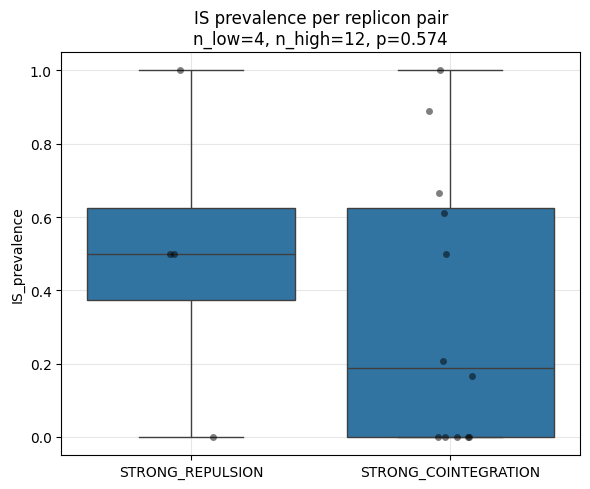

In [54]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_plot,
    x="category",
    y="IS_prevalence",
    order=["STRONG_REPULSION","STRONG_COINTEGRATION"],
    showfliers=False
)

sns.stripplot(
    data=df_plot,
    x="category",
    y="IS_prevalence",
    color="black",
    alpha=0.5
)

# estadística
g1 = df_plot[df_plot["category"]=="STRONG_REPULSION"]["IS_prevalence"]
g2 = df_plot[df_plot["category"]=="STRONG_COINTEGRATION"]["IS_prevalence"]

u, p = mannwhitneyu(g1, g2, alternative="two-sided")

plt.title(
    f"IS prevalence per replicon pair\n"
    f"n_low={len(g1)}, n_high={len(g2)}, p={p:.3g}"
)

plt.ylabel("IS_prevalence")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
full

,repA_x,repB_x,n_same_cell_x,n_cell_same_plasmid_x,cointegration_rate_x,ci_low_x,ci_high_x,category_x,rep_pair,n,...,p_cov_gt_01,p_cov_gt_05,repA_y,repB_y,n_same_cell_y,n_cell_same_plasmid_y,cointegration_rate_y,ci_low_y,ci_high_y,category_y
0,IncFIB,IncFII,3035,2410,0.794069,0.779238,0.808332,MIXED,IncFIB || IncFII,1291,...,0.775798,0.295261,IncFIB,IncFII,3035.0,2410.0,0.794069,0.779238,0.808332,MIXED
1,IncFIB,rep_cluster_2183,1051,825,0.784967,0.758872,0.809455,MIXED,IncFIB || rep_cluster_2183,365,...,0.734279,0.200250,IncFIB,rep_cluster_2183,1051.0,825.0,0.784967,0.758872,0.809455,MIXED
2,IncFII,IncR,776,383,0.493557,0.457818,0.529345,MIXED,IncFII || IncR,214,...,0.901793,0.355486,IncFII,IncR,776.0,383.0,0.493557,0.457818,0.529345,MIXED
3,IncFII,rep_cluster_2183,1139,1126,0.988586,0.980562,0.993909,STRONG_COINTEGRATION,IncFII || rep_cluster_2183,656,...,0.768601,0.286935,IncFII,rep_cluster_2183,1139.0,1126.0,0.988586,0.980562,0.993909,STRONG_COINTEGRATION
4,IncR,rep_cluster_2183,370,90,0.243243,0.200382,0.290266,MIXED,IncR || rep_cluster_2183,98,...,0.879743,0.280400,IncR,rep_cluster_2183,370.0,90.0,0.243243,0.200382,0.290266,MIXED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,rep_cluster_1216,rep_cluster_1733,12,12,1.000000,0.735352,1.000000,STRONG_COINTEGRATION,rep_cluster_1216 || rep_cluster_1733,9,...,1.000000,0.000000,rep_cluster_1216,rep_cluster_1733,12.0,12.0,1.000000,0.735352,1.000000,STRONG_COINTEGRATION
86,rep_cluster_1110,rep_cluster_1442,14,10,0.714286,0.418965,0.916111,MIXED,rep_cluster_1110 || rep_cluster_1442,8,...,0.903226,0.387097,rep_cluster_1110,rep_cluster_1442,14.0,10.0,0.714286,0.418965,0.916111,MIXED
87,rep_cluster_1118,rep_cluster_980,35,21,0.600000,0.421118,0.761292,MIXED,rep_cluster_1118 || rep_cluster_980,15,...,0.966667,0.562500,rep_cluster_1118,rep_cluster_980,35.0,21.0,0.600000,0.421118,0.761292,MIXED
88,rep_cluster_1118,rep_cluster_992,67,62,0.925373,0.834374,0.975325,STRONG_COINTEGRATION,rep_cluster_1118 || rep_cluster_992,28,...,0.878788,0.472727,rep_cluster_1118,rep_cluster_992,67.0,62.0,0.925373,0.834374,0.975325,STRONG_COINTEGRATION



===== EVENT SUMMARY =====
category
0 IS                653
1 IS                601
2 IS (same)         196
2 IS (different)    167
Name: count, dtype: int64


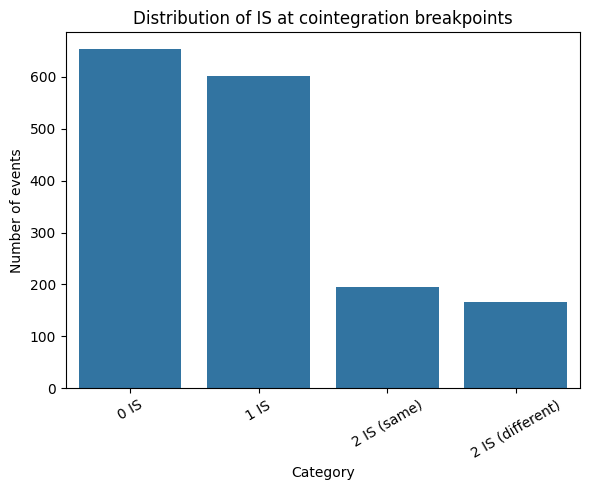

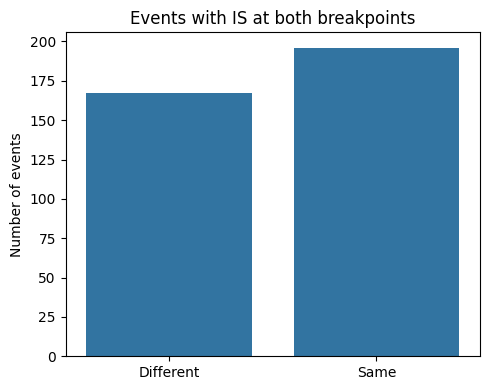

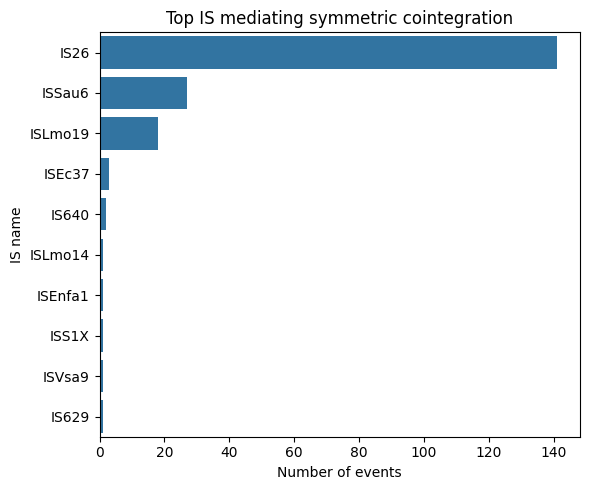

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PREP
# ============================================================

df = df_event.copy()

df["n_IS"] = df["bp1_IS_present"] + df["bp2_IS_present"]

def split_IS(x):
    if x == "NA":
        return set()
    return set(x.split(";"))

df["bp1_set"] = df["bp1_IS_names"].apply(split_IS)
df["bp2_set"] = df["bp2_IS_names"].apply(split_IS)

df["same_IS"] = (
    (df["n_IS"] == 2) &
    (df["bp1_set"] == df["bp2_set"])
)

# Categoría final
def classify(row):
    if row["n_IS"] == 0:
        return "0 IS"
    elif row["n_IS"] == 1:
        return "1 IS"
    elif row["n_IS"] == 2 and row["same_IS"]:
        return "2 IS (same)"
    elif row["n_IS"] == 2:
        return "2 IS (different)"

df["category"] = df.apply(classify, axis=1)

# ============================================================
# SUMMARY NUMBERS
# ============================================================

summary = df["category"].value_counts()

print("\n===== EVENT SUMMARY =====")
print(summary)

# ============================================================
# PLOT 1 — GLOBAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,5))
sns.barplot(
    x=summary.index,
    y=summary.values
)
plt.ylabel("Number of events")
plt.xlabel("Category")
plt.title("Distribution of IS at cointegration breakpoints")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2 — ONLY EVENTS WITH 2 IS
# ============================================================

two_IS = df[df["n_IS"] == 2]
two_summary = two_IS["same_IS"].value_counts()

plt.figure(figsize=(5,4))
sns.barplot(
    x=["Different", "Same"],
    y=[
        two_summary.get(False,0),
        two_summary.get(True,0)
    ]
)
plt.ylabel("Number of events")
plt.title("Events with IS at both breakpoints")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3 — WHICH IS MEDIATE SYMMETRIC EVENTS
# ============================================================

same_df = df[df["category"] == "2 IS (same)"]

same_IS_counts = (
    same_df["bp1_IS_names"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(6,5))
sns.barplot(
    x=same_IS_counts.values,
    y=same_IS_counts.index
)
plt.xlabel("Number of events")
plt.ylabel("IS name")
plt.title("Top IS mediating symmetric cointegration")
plt.tight_layout()
plt.show()

In [146]:
import pandas as pd

# ============================================================
# 1. PARTIR DE df_event
# ============================================================

df = df_event.copy()

df["n_IS"] = df["bp1_IS_present"] + df["bp2_IS_present"]

def split_IS(x):
    if pd.isna(x) or x == "NA" or x == "":
        return set()
    return set(str(x).split(";"))

df["bp1_set"] = df["bp1_IS_names"].apply(split_IS)
df["bp2_set"] = df["bp2_IS_names"].apply(split_IS)

df["same_IS"] = (
    (df["n_IS"] == 2) &
    (df["bp1_set"] == df["bp2_set"])
)

# ============================================================
# 2. QUEDARSE CON EVENTOS 2 IS (same)
# ============================================================

same_df = df[df["same_IS"]].copy()

print("Número de eventos 2 IS (same):", len(same_df))

# ============================================================
# 3. CARGAR MOBILITY
# ============================================================

typing_path = "/home/nacho/Downloads/meta/typing.csv"
typing = pd.read_csv(typing_path, sep=",")   # si falla, prueba sep=","

typing["NUCCORE_ACC"] = typing["NUCCORE_ACC"].astype(str)

# ============================================================
# 4. EXTRAER PLÁSMIDOS ÚNICOS
# ============================================================
# Cambia 'plasmid_id' por el nombre real de la columna en df_event
# si en tu tabla se llama distinto

plasmid_col = "big_plasmid"

same_plasmids = (
    same_df[[plasmid_col]]
    .drop_duplicates()
    .rename(columns={plasmid_col: "NUCCORE_ACC"})
)

print("Número de plásmidos únicos con eventos 2 IS (same):", len(same_plasmids))

# ============================================================
# 5. MERGE CON MOVILIDAD
# ============================================================

same_plasmids = same_plasmids.merge(
    typing[["NUCCORE_ACC", "predicted_mobility"]],
    on="NUCCORE_ACC",
    how="left"
)

print("\nPlásmidos sin movilidad asignada:",
      same_plasmids["predicted_mobility"].isna().sum())

# ============================================================
# 6. RESUMEN DE MOVILIDAD
# ============================================================

mobility_counts = (
    same_plasmids["predicted_mobility"]
    .fillna("NA")
    .value_counts()
)

print("\n===== MOVILIDAD DE PLÁSMIDOS CON 2 IS (same) =====")
print(mobility_counts)

print("\nProporciones:")
print((mobility_counts / mobility_counts.sum()).round(3))

# ============================================================
# 7. VER LA TABLA FINAL
# ============================================================

print("\nPrimeros plásmidos:")
print(same_plasmids.head(20))

Número de eventos 2 IS (same): 196
Número de plásmidos únicos con eventos 2 IS (same): 139

Plásmidos sin movilidad asignada: 0

===== MOVILIDAD DE PLÁSMIDOS CON 2 IS (same) =====
predicted_mobility
mobilizable        54
conjugative        49
non-mobilizable    36
Name: count, dtype: int64

Proporciones:
predicted_mobility
mobilizable        0.388
conjugative        0.353
non-mobilizable    0.259
Name: count, dtype: float64

Primeros plásmidos:
      NUCCORE_ACC predicted_mobility
0   NZ_CP017798.1    non-mobilizable
1   NZ_OR095737.1        mobilizable
2   NZ_CP017086.1        mobilizable
3      CP067912.1        mobilizable
4      CP027485.1        conjugative
5      CP088403.1        conjugative
6      CP088651.1        mobilizable
7      CP088712.1    non-mobilizable
8      CP101349.1    non-mobilizable
9   NZ_CP023947.1    non-mobilizable
10  NZ_CP028389.3        conjugative
11  NZ_CP030308.1    non-mobilizable
12  NZ_CP033761.1        conjugative
13  NZ_CP034401.1        conjugat

In [145]:
print(df_event.head)

<bound method NDFrame.head of         big_plasmid  small_plasmid             bp1_IS_names  \
0     NZ_CP068038.1     AP024697.1                       NA   
1     NZ_CP017798.1     AP026592.1                  ISLmo19   
2     NZ_CP018827.1  NZ_CP096217.1                       NA   
3     NZ_CP023800.1  NZ_CP096217.1                       NA   
4     NZ_CP096212.1     AP026592.1  ISLmo19;cn_1273_ISLmo19   
...             ...            ...                      ...   
1612    NC_013332.1  NZ_CP150656.1                   ISSau6   
1613  NZ_CP012121.2  NZ_CP150656.1                   ISSep1   
1614  NZ_CP016854.1  NZ_CP150656.1                   ISSau6   
1615  NZ_CP062381.1  NZ_KY436021.1     ISSau6;cn_922_ISSau6   
1616  NZ_MN200130.1  NZ_MN200129.1                       NA   

                                  bp1_IS_type  bp1_IS_present bp2_IS_names  \
0                                          NA               0           NA   
1                          insertion sequence            

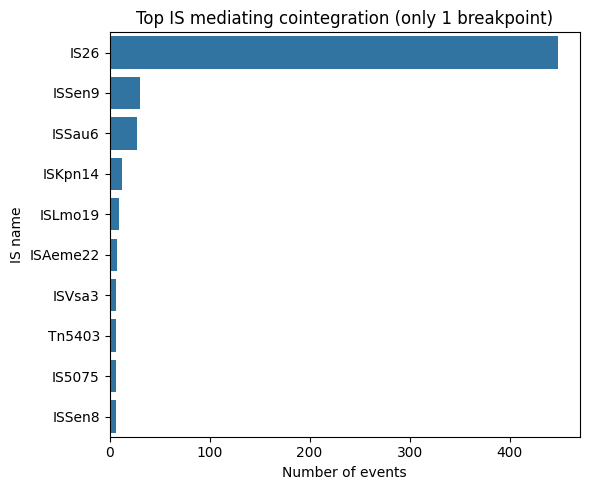

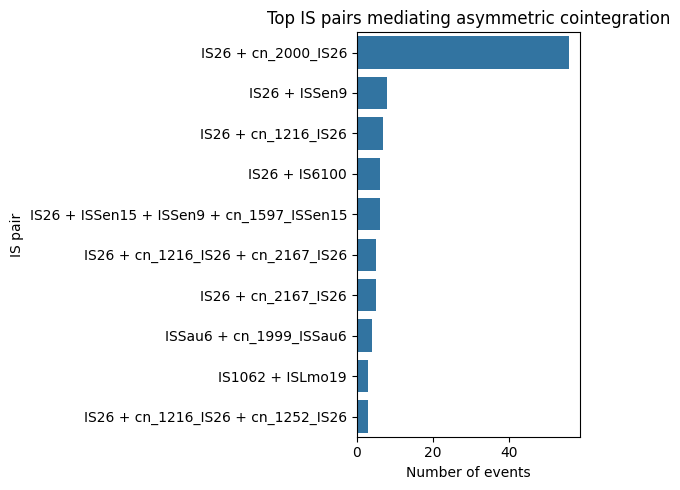

In [93]:
# ============================================================
# PLOT 4 — TOP IS WHEN THERE IS EXACTLY 1 IS
# ============================================================

one_IS_df = df[df["category"] == "1 IS"].copy()

def get_single_IS(row):
    if row["bp1_IS_present"] == 1:
        return list(row["bp1_set"])[0]
    elif row["bp2_IS_present"] == 1:
        return list(row["bp2_set"])[0]
    else:
        return None

one_IS_df["single_IS"] = one_IS_df.apply(get_single_IS, axis=1)

single_counts = (
    one_IS_df["single_IS"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(6,5))
sns.barplot(
    x=single_counts.values,
    y=single_counts.index
)
plt.xlabel("Number of events")
plt.ylabel("IS name")
plt.title("Top IS mediating cointegration (only 1 breakpoint)")
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 5 — TOP PAIRS WHEN THERE ARE 2 DIFFERENT IS
# ============================================================

diff_df = df[df["category"] == "2 IS (different)"].copy()

def build_pair(row):
    pair = list(row["bp1_set"] | row["bp2_set"])
    pair = sorted(pair)
    return " + ".join(pair)

diff_df["IS_pair"] = diff_df.apply(build_pair, axis=1)

pair_counts = (
    diff_df["IS_pair"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(6,5))
sns.barplot(
    x=pair_counts.values,
    y=pair_counts.index
)
plt.xlabel("Number of events")
plt.ylabel("IS pair")
plt.title("Top IS pairs mediating asymmetric cointegration")
plt.tight_layout()
plt.show()

In [99]:
# ============================================================
# 1. LOAD META FILES (MISMO ORIGEN QUE EL OTRO NOTEBOOK)
# ============================================================

import pandas as pd
import ast

nuccore  = pd.read_csv("/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/meta/nuccore.csv")
assembly = pd.read_csv("/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/meta/assembly.csv")

# ============================================================
# 2. EXTRACT GENUS (MISMA LÓGICA EXACTA)
# ============================================================

nuccore["GENUS"] = (
    nuccore["NUCCORE_Description"]
    .astype(str)
    .str.strip()
    .str.split()
    .str[0]
    .str.capitalize()
)

# ============================================================
# 3. MAP ASSEMBLY → NUCCORE
# ============================================================

def safe_eval(x):
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return x

assembly["NUCCORE_UID"] = assembly["NUCCORE_UID"].apply(safe_eval)

assembly_long = (
    assembly
    .explode("NUCCORE_UID")
    .dropna(subset=["NUCCORE_UID"])
)

df_meta = assembly_long.merge(
    nuccore[["NUCCORE_UID", "NUCCORE_ACC", "GENUS"]],
    on="NUCCORE_UID",
    how="left"
)

# ============================================================
# 4. BUILD MAP: plasmid accession → GENUS
# ============================================================

genus_map = (
    df_meta[["NUCCORE_ACC", "GENUS"]]
    .dropna()
    .drop_duplicates()
)

# ============================================================
# 5. MERGE INTO df_event USING plasmid_big
# ============================================================

df_event = df_event.merge(
    genus_map,
    left_on="big_plasmid",      # plasmid_big debe ser NUCCORE_ACC
    right_on="NUCCORE_ACC",
    how="left"
)

df_event = df_event.drop(columns=["NUCCORE_ACC"])

# Renombramos para consistencia
df_event = df_event.rename(columns={"GENUS": "genus"})

# ============================================================
# 6. CHECK
# ============================================================

print("Total events:", len(df_event))
print("Events with genus:", df_event["genus"].notna().sum())
print("Missing genus:", df_event["genus"].isna().sum())
print("\nTop genera:")
print(df_event["genus"].value_counts().head(10))

Total events: 1617
Events with genus: 1187
Missing genus: 430

Top genera:
genus
Klebsiella             401
Escherichia            372
Staphylococcus         159
Salmonella              87
Enterococcus            49
Enterobacter            41
Citrobacter             25
Shigella                11
Proteus                  6
Lactiplantibacillus      5
Name: count, dtype: int64



================ Klebsiella =================
Total events: 401


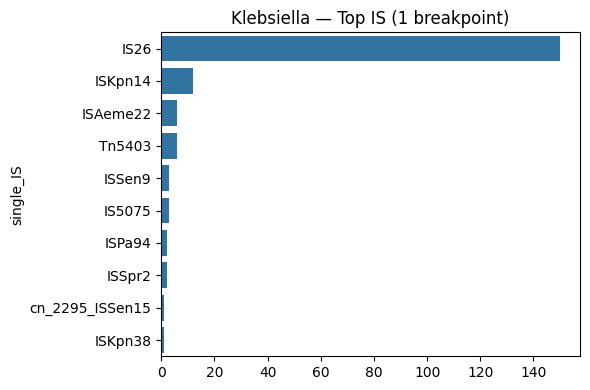

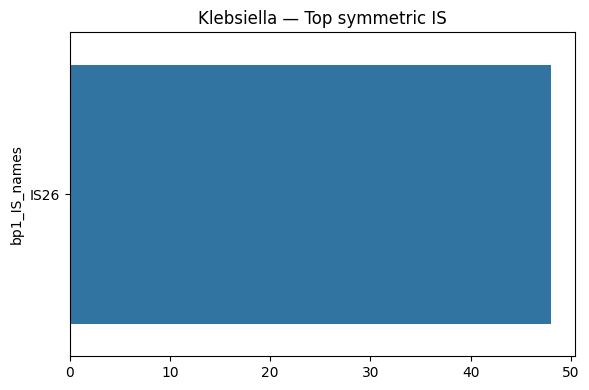

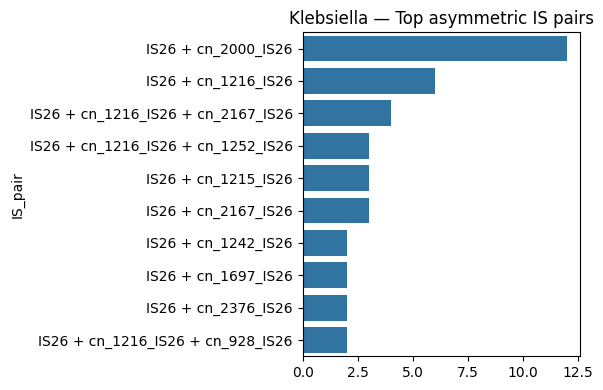


================ Escherichia =================
Total events: 372


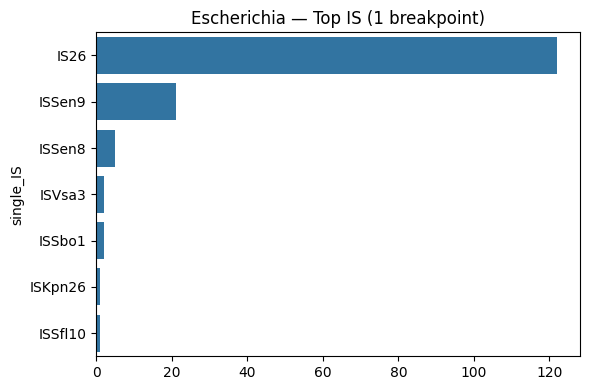

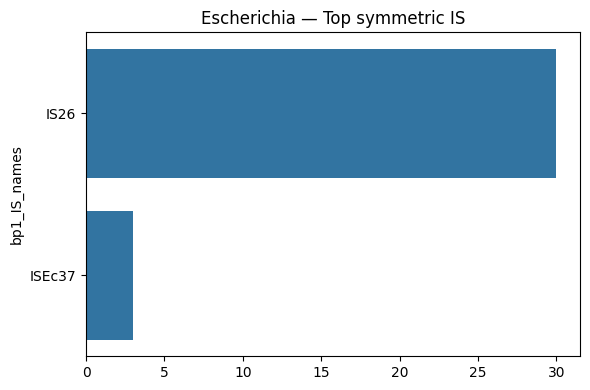

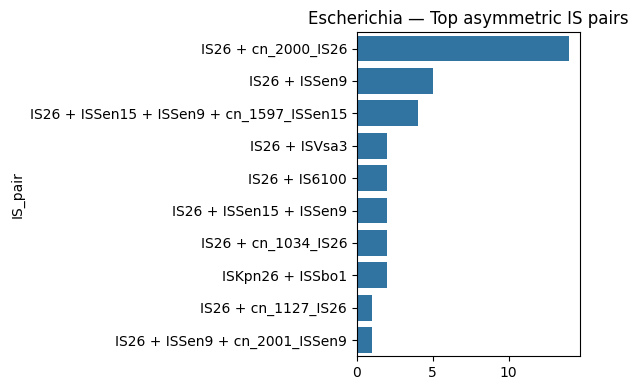


================ Staphylococcus =================
Total events: 159


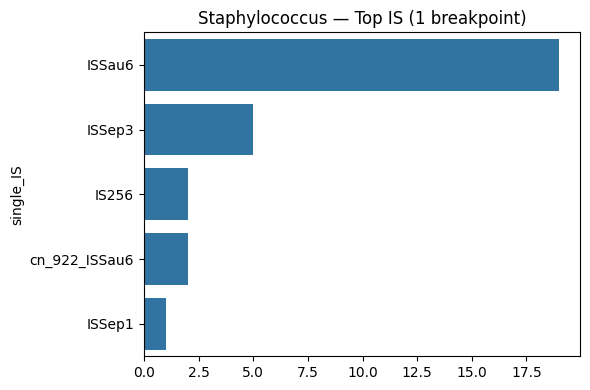

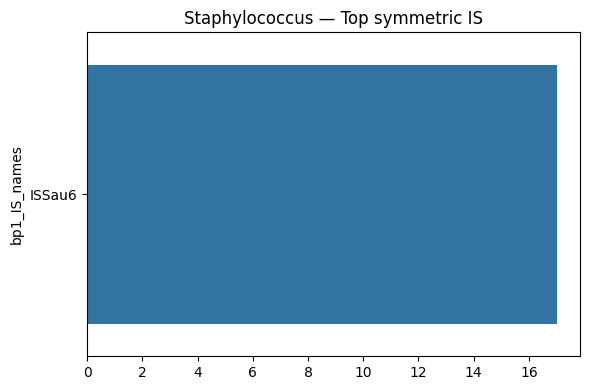

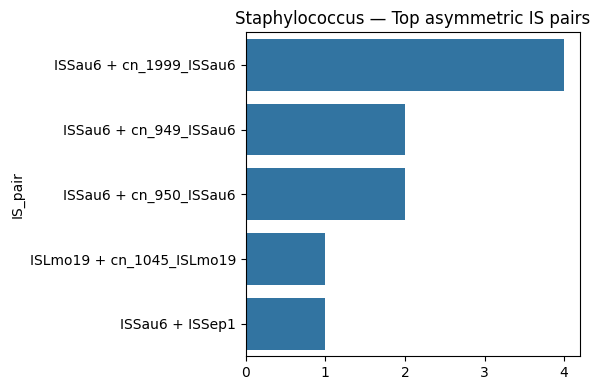


================ Salmonella =================
Total events: 87


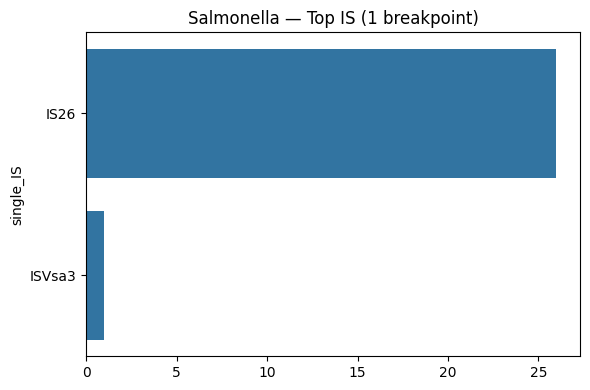

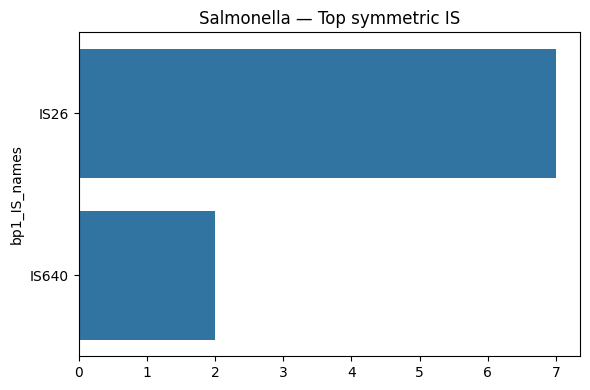

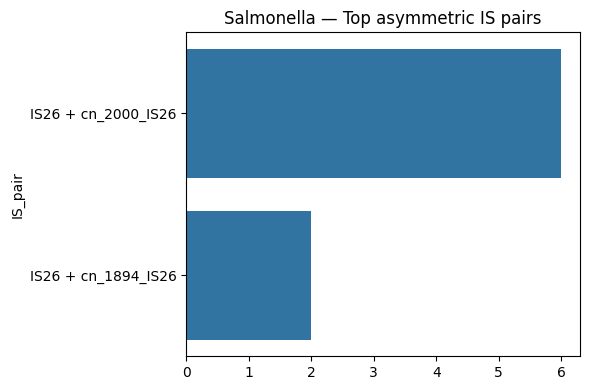


================ Enterococcus =================
Total events: 49


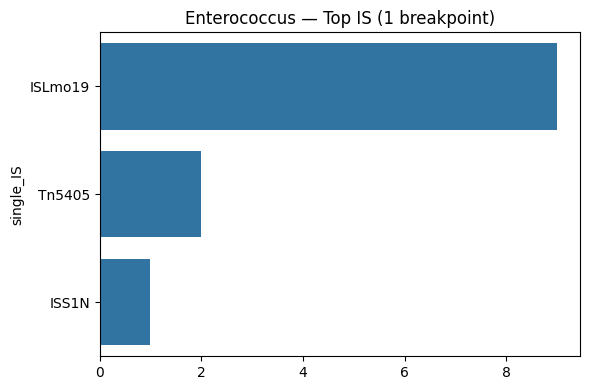

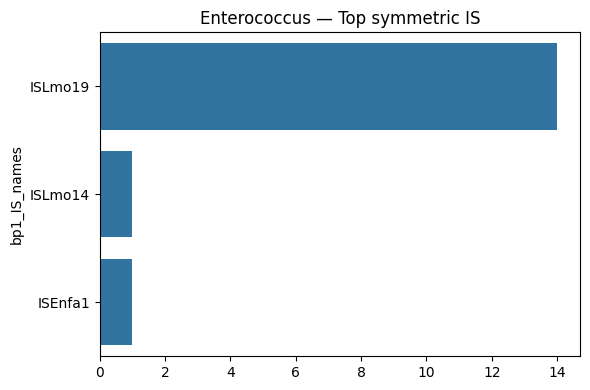

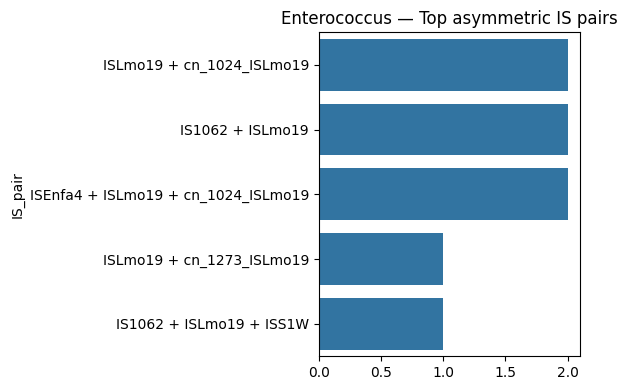


================ Enterobacter =================
Total events: 41


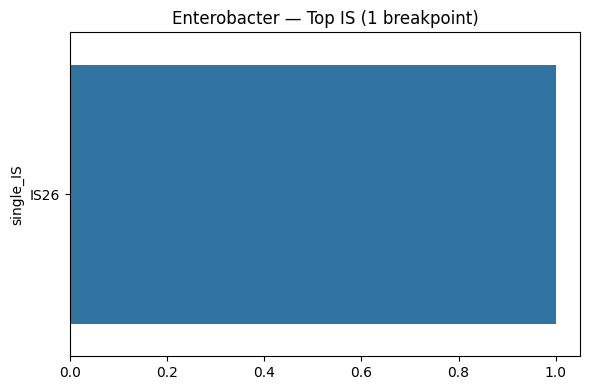

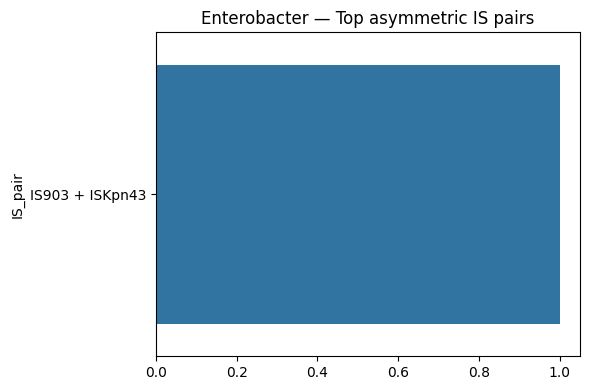

In [102]:
# ============================================================
# REBUILD DERIVED COLUMNS
# ============================================================

df = df_event.copy()

df["n_IS"] = df["bp1_IS_present"] + df["bp2_IS_present"]

def split_IS(x):
    if pd.isna(x) or x == "NA":
        return set()
    return set(x.split(";"))

df["bp1_set"] = df["bp1_IS_names"].apply(split_IS)
df["bp2_set"] = df["bp2_IS_names"].apply(split_IS)

df["same_IS"] = (
    (df["n_IS"] == 2) &
    (df["bp1_set"] == df["bp2_set"])
)

def classify(row):
    if row["n_IS"] == 0:
        return "0 IS"
    elif row["n_IS"] == 1:
        return "1 IS"
    elif row["n_IS"] == 2 and row["same_IS"]:
        return "2 IS (same)"
    elif row["n_IS"] == 2:
        return "2 IS (different)"

df["category"] = df.apply(classify, axis=1)

# ============================================================
# STRATIFY BY GENUS
# ============================================================

main_genera = [
    "Klebsiella",
    "Escherichia",
    "Staphylococcus",
    "Salmonella",
    "Enterococcus",
    "Enterobacter"
]

df_gen = df[df["genus"].isin(main_genera)].copy()

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_single_IS(row):
    if row["bp1_IS_present"] == 1:
        return list(row["bp1_set"])[0]
    elif row["bp2_IS_present"] == 1:
        return list(row["bp2_set"])[0]
    return None

def build_pair(row):
    pair = list(row["bp1_set"] | row["bp2_set"])
    pair = sorted(pair)
    return " + ".join(pair)

# ============================================================
# LOOP PER GENUS
# ============================================================

for g in main_genera:

    sub = df_gen[df_gen["genus"] == g]

    if len(sub) == 0:
        continue

    print(f"\n================ {g} =================")
    print("Total events:", len(sub))

    # -----------------------------
    # 1 IS
    # -----------------------------
    one_IS = sub[sub["category"] == "1 IS"].copy()
    one_IS["single_IS"] = one_IS.apply(get_single_IS, axis=1)

    top_single = one_IS["single_IS"].value_counts().head(10)

    if len(top_single) > 0:
        plt.figure(figsize=(6,4))
        sns.barplot(x=top_single.values, y=top_single.index)
        plt.title(f"{g} — Top IS (1 breakpoint)")
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # 2 IS (same)
    # -----------------------------
    same_IS = sub[sub["category"] == "2 IS (same)"]
    top_same = same_IS["bp1_IS_names"].value_counts().head(10)

    if len(top_same) > 0:
        plt.figure(figsize=(6,4))
        sns.barplot(x=top_same.values, y=top_same.index)
        plt.title(f"{g} — Top symmetric IS")
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # 2 IS (different)
    # -----------------------------
    diff_IS = sub[sub["category"] == "2 IS (different)"].copy()
    diff_IS["IS_pair"] = diff_IS.apply(build_pair, axis=1)

    top_pairs = diff_IS["IS_pair"].value_counts().head(10)

    if len(top_pairs) > 0:
        plt.figure(figsize=(6,4))
        sns.barplot(x=top_pairs.values, y=top_pairs.index)
        plt.title(f"{g} — Top asymmetric IS pairs")
        plt.tight_layout()
        plt.show()

In [149]:
import os
import pandas as pd

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
HALF_WINDOWS = [500,1000,1500,2000,2500]

def read_set(path):
    if not os.path.exists(path) or os.path.getsize(path) < 50:
        return set()
    df = pd.read_csv(path, sep=",", comment="#")
    if df.shape[0] == 0:
        return set()
    return set(df["name"].astype(str).unique())

def classify_pair(set1, set2):

    has1 = len(set1) > 0
    has2 = len(set2) > 0

    if not has1 and not has2:
        return "0 IS"

    if has1 ^ has2:
        return "1 IS"

    # ambos tienen al menos 1 IS
    if len(set1.intersection(set2)) > 0:
        return "2 IS (same)"

    return "2 IS (different)"


all_rows = []

for hw in HALF_WINDOWS:

    WINDOW = hw * 2
    RESULT_DIR = os.path.join(BASE_DIR, f"FULL_hyper_{hw}")

    print("\nWindow:", WINDOW)

    # -------------------------------------------------
    # Count how many bp files exist (exact hyperpal logic)
    # -------------------------------------------------

    i = 0
    while True:
        test_file = os.path.join(RESULT_DIR, f"bp_{i}.csv")
        if not os.path.exists(test_file):
            break
        i += 1

    n_bp = i
    print("Total bp files:", n_bp)

    n_events = n_bp // 2
    print("Total events:", n_events)

    real_cats = []
    bg_cats = []
    chr_cats = []

    # -------------------------------------------------
    # Iterate by event index
    # -------------------------------------------------

    for event_id in range(n_events):

        # ---- REAL ----
        bp1 = os.path.join(RESULT_DIR, f"bp_{2*event_id}.csv")
        bp2 = os.path.join(RESULT_DIR, f"bp_{2*event_id+1}.csv")

        set1 = read_set(bp1)
        set2 = read_set(bp2)
        real_cats.append(classify_pair(set1, set2))

        # ---- RANDOM PLASMID ----
        bg1 = os.path.join(RESULT_DIR, f"bg_{2*event_id}.csv")
        bg2 = os.path.join(RESULT_DIR, f"bg_{2*event_id+1}.csv")

        if os.path.exists(bg1) and os.path.exists(bg2):
            set1 = read_set(bg1)
            set2 = read_set(bg2)
            bg_cats.append(classify_pair(set1, set2))

        # ---- CHROMOSOME ----
        chr1 = os.path.join(RESULT_DIR, f"chr_{2*event_id}.csv")
        chr2 = os.path.join(RESULT_DIR, f"chr_{2*event_id+1}.csv")

        if os.path.exists(chr1) and os.path.exists(chr2):
            set1 = read_set(chr1)
            set2 = read_set(chr2)
            chr_cats.append(classify_pair(set1, set2))

    # -------------------------------------------------
    # Compute proportions
    # -------------------------------------------------

    def get_props(cat_list):
        s = pd.Series(cat_list)
        return s.value_counts(normalize=True)

    real_props = get_props(real_cats)
    bg_props = get_props(bg_cats)
    chr_props = get_props(chr_cats)

    for cat in ["1 IS", "2 IS (same)", "2 IS (different)"]:
        all_rows.append({
            "window": WINDOW,
            "category": cat,
            "real": real_props.get(cat, 0),
            "random_plasmid": bg_props.get(cat, 0),
            "chromosome": chr_props.get(cat, 0)
        })

df_curves = pd.DataFrame(all_rows)
df_curves.to_csv("mechanistic_curves.tsv", sep="\t", index=False)

print("\nMechanistic curves written.")


Window: 1000
Total bp files: 3234
Total events: 1617

Window: 2000
Total bp files: 3234
Total events: 1617

Window: 3000
Total bp files: 2772
Total events: 1386

Window: 4000
Total bp files: 3234
Total events: 1617

Window: 5000
Total bp files: 3234
Total events: 1617

Mechanistic curves written.


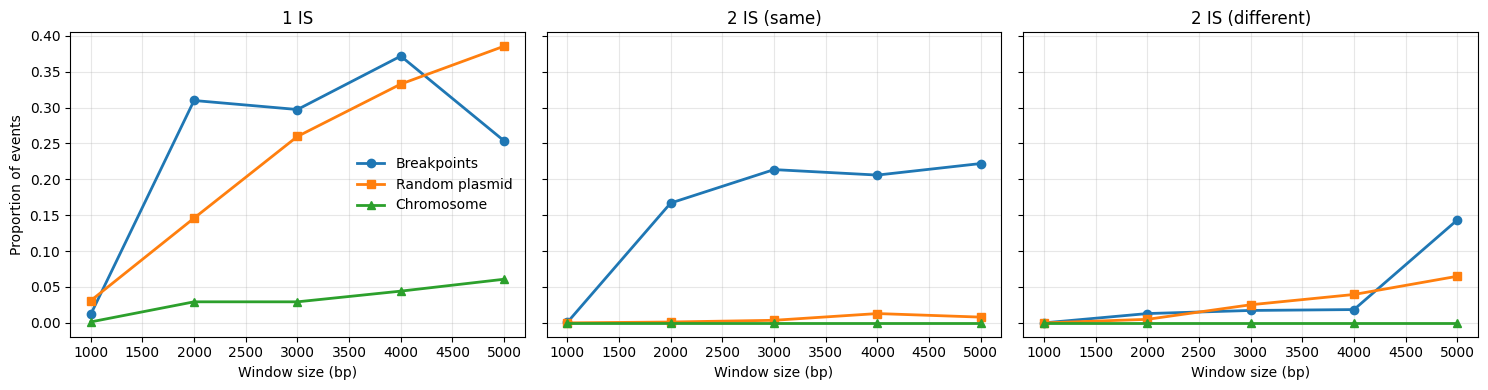

In [110]:
import matplotlib.pyplot as plt

categories = ["1 IS", "2 IS (same)", "2 IS (different)"]

fig, axes = plt.subplots(1,3, figsize=(15,4), sharey=True)

for ax, cat in zip(axes, categories):

    sub = df_curves[df_curves["category"] == cat]

    ax.plot(sub["window"], sub["real"],
            marker="o", linewidth=2, label="Breakpoints")

    ax.plot(sub["window"], sub["random_plasmid"],
            marker="s", linewidth=2, label="Random plasmid")

    ax.plot(sub["window"], sub["chromosome"],
            marker="^", linewidth=2, label="Chromosome")

    ax.set_title(cat)
    ax.set_xlabel("Window size (bp)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Proportion of events")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()